In [ ]:
from google.colab import drive
drive.mount('/content/drive')



Mounted at /content/drive


In [ ]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/Projects_AI_DS/bearing_fault/IMS.zip"
extract_path = "/content/mydata"

# Create folder if not exists
os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extracted files:", os.listdir(extract_path))


Extracted files: ['IMS', '__MACOSX']


In [ ]:
import os

data_dir = "/content/mydata/IMS/"

for root, dirs, files in os.walk(data_dir):
    print("ROOT:", root)
    print("NUM FILES:", len(files))
    print("FILES SAMPLE:", files[:5])
    print("-----")

ROOT: /content/mydata/IMS/
NUM FILES: 4
FILES SAMPLE: ['1st_test.rar', '2nd_test.rar', 'Readme Document for IMS Bearing Data.pdf', '3rd_test.rar']
-----


In [ ]:
import os

data_dir = "/content/mydata/IMS"
print("Files inside IMS:", os.listdir(data_dir)[:10])


Files inside IMS: ['1st_test.rar', 'Readme Document for IMS Bearing Data.pdf', '2nd_test.rar', '3rd_test.rar']


In [ ]:
!apt-get install -y unrar

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
unrar is already the newest version (1:6.1.5-1ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 38 not upgraded.


In [ ]:
!unrar x "/content/mydata/IMS/1st_test.rar" "/content/mydata/IMS/1st_test/"



UNRAR 6.11 beta 1 freeware      Copyright (c) 1993-2022 Alexander Roshal


Extracting from /content/mydata/IMS/1st_test.rar

Creating    /content/mydata/IMS/1st_test                              OK
Creating    /content/mydata/IMS/1st_test/1st_test                     OK
Extracting  /content/mydata/IMS/1st_test/1st_test/2003.10.22.12.06.24       0%  OK 
Extracting  /content/mydata/IMS/1st_test/1st_test/2003.10.22.12.09.13       0%  OK 
Extracting  /content/mydata/IMS/1st_test/1st_test/2003.10.22.12.14.13       0%  OK 
Extracting  /content/mydata/IMS/1st_test/1st_test/2003.10.22.12.19.13       0%  OK 
Extracting  /content/mydata/IMS/1st_test/1st_test/2003.10.22.12.24.13       0%  OK 
Extracting  /content/mydata/IMS/1st_test/1st_test/2003.10.22.12.29.13       0%  OK 
Extracting  /content/mydata/IMS/1st_test/1st_test/2003.10.22.12.34.13       0%  OK 
Extracting  /content/mydata/IMS/1st_test/1st_test/2003.10.22.12.39.13     

In [ ]:
import os

path = "/content/mydata/IMS/1st_test"
print("Files inside 1st_test:", os.listdir(path)[:10])


Files inside 1st_test: ['1st_test']


In [ ]:
import os

folder_path = "/content/mydata/IMS/1st_test/1st_test"
files = os.listdir(folder_path)
print(len(files))   # how many files
print(files[:10])   # first 10 files


2156
['2003.11.15.21.58.46', '2003.11.14.13.22.17', '2003.10.31.01.19.46', '2003.10.31.23.41.44', '2003.11.23.22.31.24', '2003.11.20.13.19.03', '2003.11.23.03.16.56', '2003.11.21.11.48.36', '2003.11.22.06.56.56', '2003.11.16.12.28.46']


In [ ]:
import pandas as pd

file_path = "/content/mydata/IMS/1st_test/1st_test/2003.11.21.04.14.03"

# Each file is just columns of numbers (no header)
df = pd.read_csv(file_path, sep="\t", header=None)

print(df.shape)   # rows × columns
print(df.head())


(20480, 8)
       0      1      2      3      4      5      6      7
0 -0.190 -0.073 -0.300 -0.066  0.071 -0.291 -0.083 -0.129
1 -0.132 -0.017 -0.229 -0.137  0.068 -0.222 -0.122 -0.107
2 -0.205 -0.134  0.076 -0.156 -0.193 -0.330 -0.149 -0.129
3 -0.161 -0.266  0.059 -0.300 -0.176 -0.017 -0.217 -0.217
4 -0.083 -0.134 -0.095 -0.103  0.073 -0.210 -0.083 -0.112


**rolling windows**

In [ ]:
import numpy as np

window_size = 1024
stride = 512  # 50% overlap
segments = []

for start in range(0, df.shape[0] - window_size, stride):
    segment = df.iloc[start:start+window_size].values
    segments.append(segment)

segments = np.array(segments)
print(segments.shape)  # (num_segments, 1024, 8)


(38, 1024, 8)


**feature extraction**

In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import skew, kurtosis
from scipy.fft import fft

# Assume 'segments' is your numpy array of shape (38, 1024, 8)
X_features = []

for seg in segments:  # seg.shape = (1024, 8)
    feats = []
    for ch in range(seg.shape[1]):
        signal = seg[:, ch]
        # Time domain
        feats.append(np.mean(signal))
        feats.append(np.std(signal))
        feats.append(np.sqrt(np.mean(signal**2)))  # RMS
        feats.append(skew(signal))
        feats.append(kurtosis(signal))
        feats.append(np.ptp(signal))  # Peak-to-peak
        # Frequency domain
        freqs = np.abs(fft(signal))
        feats.append(np.argmax(freqs))  # dominant frequency index
    X_features.append(feats)

X_features = np.array(X_features)
print("Feature matrix shape:", X_features.shape)  # (38, 8*7=56 features)


Feature matrix shape: (38, 56)


In [ ]:
y = np.zeros(X_features.shape[0])


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

clf = RandomForestClassifier(n_estimators=100, random_state=42)
scores = cross_val_score(clf, X_features, y, cv=5)  # 5-fold CV
print("CV Accuracy scores:", scores)
print("Mean CV Accuracy:", np.mean(scores))


CV Accuracy scores: [1. 1. 1. 1. 1.]
Mean CV Accuracy: 1.0


In [ ]:
# Install FPDF
!pip install fpdf --quiet

# Import FPDF
from fpdf import FPDF

# Create PDF object
pdf = FPDF()
pdf.add_page()
pdf.set_font("Arial", size=12)

# Document text (plain ASCII, safe for FPDF)
text = """
Predictive Maintenance on IMS Bearing Dataset - Progress Document

Project Goal:
Predict bearing condition (healthy or faulty) using vibration signals from the IMS Bearing Dataset.

1. Dataset Setup
- Extracted zip: /content/mydata/IMS/
- Contents: ['1st_test', 'Readme Document for IMS Bearing Data.pdf', '2nd_test.rar', '3rd_test.rar', '1st_test.rar']
- Already extracted: 1st_test -> contains 2156 files, each raw vibration signal (~1024 time steps x 8 channels).

2. Current File Structure
- Path to first test data: /content/mydata/IMS/1st_test/1st_test
- Example files: ['2003.11.21.04.14.03', ...]
- Each file has 8 channels of vibration data, 20480 rows per file.

3. Data Loading
- Loaded a sample file:
  import pandas as pd
  df = pd.read_csv(file_path, sep="\\t", header=None)
  df.shape  # (20480, 8)

- Segmented into windows (1024 samples, 50% overlap):
  segments.shape  # (38, 1024, 8)

4. Feature Extraction
- Time-domain: mean, std, RMS, skewness, kurtosis, peak-to-peak
- Frequency-domain: dominant frequency via FFT
- Resulting feature matrix shape: (38, 56)

5. Labels
- Dummy labels for one file: y = np.zeros(38)

6. ML Model - Random Forest
- Training on one file to confirm pipeline works
- CV Accuracy scores: [1.0, 1.0, 1.0, 1.0, 1.0]
- Mean CV Accuracy: 1.0

7. Next Steps
1. Extract 2nd_test.rar and 3rd_test.rar
2. Segment all files
3. Assign real labels: healthy=0, inner race fault=1, outer race fault=2, ball fault=3
4. Extract features -> full dataset (X, y)
5. Train ML models (Random Forest, XGBoost, SVM)
6. Evaluate using cross-validation
7. Optional: move to deep learning (1D-CNN / CNN+LSTM)
"""

# Add text to PDF
for line in text.split("\n"):
    pdf.multi_cell(0, 6, line)

# Save PDF
pdf_path = "/content/IMS_Project_Progress.pdf"
pdf.output(pdf_path)
print("PDF saved at:", pdf_path)


  Preparing metadata (setup.py) ... done
PDF saved at: /content/IMS_Project_Progress.pdf


In [ ]:
import os
import time
import numpy as np
import pandas as pd
from scipy.stats import skew, kurtosis
from scipy.fft import fft
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupKFold, cross_val_score

# -------------------- Parameters --------------------
data_dir = "/content/mydata/IMS/"  # root directory containing all test folders
window_size = 1024
stride = 512  # 50% overlap

# Map folder names to labels
label_map = {
    "healthy": 0,
    "inner_race": 1,
    "outer_race": 2,
    "ball": 3
}

# -------------------- Functions --------------------
def segment_signal(signal, window_size=1024, stride=512):
    """Split a long signal into overlapping windows."""
    segments = []
    for start in range(0, signal.shape[0] - window_size, stride):
        segments.append(signal[start:start+window_size])
    return np.array(segments)

def extract_features(segments):
    """Extract time- and frequency-domain features from segments."""
    X_feats = []
    for seg in segments:  # seg.shape = (window_size, num_channels)
        feats = []
        for ch in range(seg.shape[1]):
            signal = seg[:, ch]
            # Time-domain
            feats.append(np.mean(signal))
            feats.append(np.std(signal))
            feats.append(np.sqrt(np.mean(signal**2)))  # RMS
            feats.append(skew(signal))
            feats.append(kurtosis(signal))
            feats.append(np.ptp(signal))  # peak-to-peak
            # Frequency-domain
            freqs = np.abs(fft(signal))
            feats.append(np.argmax(freqs))  # dominant frequency index
        X_feats.append(feats)
    return np.array(X_feats)

# -------------------- Load all files --------------------
X_all, y_all, groups = [], [], []
file_count = 0
file_id = 0
start_time = time.time()

for root, dirs, files in os.walk(data_dir):
    folder_name = os.path.basename(root).lower()
    label = label_map.get(folder_name, None)  # infer label

    for f in files:
        file_path = os.path.join(root, f)
        try:
            # Load vibration file
            df = pd.read_csv(file_path, sep="\t", header=None)

            # Segment and extract features
            segments = segment_signal(df.values, window_size, stride)
            X_feats = extract_features(segments)

            # Assign labels
            if label is not None:
                y_labels = np.full(X_feats.shape[0], label)
            else:
                y_labels = np.zeros(X_feats.shape[0])  # dummy fallback

            # Append
            if X_feats.size > 0:
                X_all.append(X_feats)
                y_all.append(y_labels)
                groups.extend([file_id] * X_feats.shape[0])
                file_id += 1

            # Progress log every 10 files
            file_count += 1
            if file_count % 100 == 0:
                elapsed = (time.time() - start_time) / 60
                print(f"[{elapsed:.2f} min] Processed {file_count} files...")

        except Exception as e:
            print(f"⚠️ Skipped {f}: {e}")

print("✅ Done. Total files processed:", file_count)

# -------------------- Combine --------------------
if X_all and y_all:
    X = np.vstack(X_all)
    y = np.hstack(y_all)
    groups = np.array(groups)

    print("Final dataset shapes:", X.shape, y.shape, groups.shape)
    print("Unique files (groups):", len(np.unique(groups)))

    # -------------------- File-wise CV --------------------
    clf = RandomForestClassifier(n_estimators=100, random_state=42)
    gkf = GroupKFold(n_splits=5)

    scores = cross_val_score(clf, X, y, cv=gkf, groups=groups)
    print("File-wise CV Accuracy scores:", scores)
    print("Mean CV Accuracy:", np.mean(scores))
else:
    print("❌ No data found. Please check folder paths and labels.")


⚠️ Skipped Readme Document for IMS Bearing Data.pdf: 'utf-8' codec can't decode byte 0xb5 in position 11: invalid start byte
⚠️ Skipped 1st_test.rar: 'utf-8' codec can't decode byte 0xc9 in position 20: invalid continuation byte
⚠️ Skipped 2nd_test.rar: 'utf-8' codec can't decode byte 0xc0 in position 20: invalid start byte
⚠️ Skipped 3rd_test.rar: 'utf-8' codec can't decode byte 0xa7 in position 20: invalid start byte
[0.90 min] Processed 100 files...
[1.75 min] Processed 200 files...
[2.59 min] Processed 300 files...
[3.44 min] Processed 400 files...
[4.29 min] Processed 500 files...
[5.14 min] Processed 600 files...
[6.00 min] Processed 700 files...
[6.85 min] Processed 800 files...
[7.68 min] Processed 900 files...
[8.53 min] Processed 1000 files...
[9.38 min] Processed 1100 files...
[10.24 min] Processed 1200 files...
[11.14 min] Processed 1300 files...
[12.00 min] Processed 1400 files...
[12.83 min] Processed 1500 files...
[13.67 min] Processed 1600 files...
[14.51 min] Processed

In [ ]:
!unrar x "/content/mydata/IMS/1st_test.rar" "/content/mydata/IMS/1st_test/"
!unrar x "/content/mydata/IMS/2nd_test.rar" "/content/mydata/IMS/2nd_test/"
!unrar x "/content/mydata/IMS/3rd_test.rar" "/content/mydata/IMS/3rd_test/"


Streaming output truncated to the last 5000 lines.
Extracting  /content/mydata/IMS/3rd_test/4th_test/txt/2004.03.13.14.12.46      17%  OK 
Extracting  /content/mydata/IMS/3rd_test/4th_test/txt/2004.03.13.14.22.46      17%  OK 
Extracting  /content/mydata/IMS/3rd_test/4th_test/txt/2004.03.13.14.32.46      17%  OK 
Extracting  /content/mydata/IMS/3rd_test/4th_test/txt/2004.03.13.14.42.46      17%  OK 
Extracting  /content/mydata/IMS/3rd_test/4th_test/txt/2004.03.13.14.52.46      17%  OK 
Extracting  /content/mydata/IMS/3rd_test/4th_test/txt/2004.03.13.15.02.46      18%  OK 
Extracting  /content/mydata/IMS/3rd_test/4th_test/txt/2004.03.13.15.12.46      18%  OK 
Extracting  /content/mydata/IMS/3rd_test/4th_test/txt/2004.03.13.15.22.46      18%  OK 
Extracting  /content/mydata/IMS/3rd_test/4th_test/txt/2004.03.13.15.32.46      18%  OK 
Extracting  /content/mydata/IMS/3rd_test/4th_test/txt/2004.03.13.15.42.46   

In [ ]:
import os

data_dir = "/content/mydata/IMS/"
all_files = []

# Walk all directories and subdirectories
for root, dirs, files in os.walk(data_dir):
    for f in files:
        # Include only IMS vibration files: usually no extension
        if not f.endswith((".pdf", ".rar")):  # ignore PDF/RAR
            all_files.append(os.path.join(root, f))

print("✅ Total files found:", len(all_files))
print("Sample files:", all_files[:10])


✅ Total files found: 9464
Sample files: ['/content/mydata/IMS/1st_test/1st_test/2003.11.21.02.54.03', '/content/mydata/IMS/1st_test/1st_test/2003.11.15.16.48.46', '/content/mydata/IMS/1st_test/1st_test/2003.10.31.20.51.44', '/content/mydata/IMS/1st_test/1st_test/2003.11.22.09.36.56', '/content/mydata/IMS/1st_test/1st_test/2003.11.24.01.51.24', '/content/mydata/IMS/1st_test/1st_test/2003.11.17.10.32.30', '/content/mydata/IMS/1st_test/1st_test/2003.11.22.09.56.56', '/content/mydata/IMS/1st_test/1st_test/2003.11.23.00.16.56', '/content/mydata/IMS/1st_test/1st_test/2003.11.15.17.28.46', '/content/mydata/IMS/1st_test/1st_test/2003.11.15.23.58.46']


In [ ]:
import os
import time
import numpy as np
import pandas as pd
from scipy.stats import skew, kurtosis
from scipy.fft import fft
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupKFold, cross_val_score, cross_val_predict
from sklearn.metrics import classification_report, confusion_matrix

# -------------------- Parameters --------------------
data_dir = "/content/mydata/IMS/"
window_size = 1024
stride = 512  # 50% overlap
sampling_rate = 20000  # Hz

# IMS test folder → fault type mapping
test_map = {
    "1st_test": "outer_race",
    "2nd_test": "inner_race",
    "3rd_test": "ball"
}

# Fault type → label id
fault_map = {
    "healthy": 0,
    "inner_race": 1,
    "outer_race": 2,
    "ball": 3
}

# -------------------- Functions --------------------
def segment_signal(signal, window_size=1024, stride=512):
    """Split a long signal into overlapping windows."""
    if signal.ndim == 1:
        signal = signal[:, None]
    segments = []
    for start in range(0, signal.shape[0] - window_size, stride):
        segments.append(signal[start:start+window_size])
    return np.array(segments)

def extract_features(segments):
    """Extract time- and frequency-domain features from segments."""
    X_feats = []
    for seg in segments:
        feats = []
        # FIX: Always use only the first channel to keep feature dimensions consistent
        signal = seg[:, 0]

        feats.append(np.mean(signal))
        feats.append(np.std(signal))
        feats.append(np.sqrt(np.mean(signal**2)))  # RMS
        feats.append(skew(signal))
        feats.append(kurtosis(signal))
        feats.append(np.ptp(signal))  # peak-to-peak

        fft_vals = np.abs(fft(signal))
        freqs = np.fft.fftfreq(len(signal), d=1/sampling_rate)
        fft_vals, freqs = fft_vals[:len(signal)//2], freqs[:len(signal)//2]
        feats.append(freqs[np.argmax(fft_vals)])  # dominant frequency (Hz)

        X_feats.append(feats)
    return np.array(X_feats)

# -------------------- Load all files --------------------
X_all, y_all, groups = [], [], []
file_count = 0
file_id = 0
start_time = time.time()

for root, dirs, files in os.walk(data_dir):
    if len(files) == 0:
        continue

    # Determine test folder
    folder_name = root.split(os.sep)[-2]  # 1st_test, 2nd_test, etc.
    fault_type = test_map.get(folder_name, None)
    if fault_type is None:
        continue

    # Sort files to separate healthy/fault
    files = sorted(files)
    split_idx = int(len(files) * 0.8)

    for i, f in enumerate(files):
        file_path = os.path.join(root, f)
        try:
            df = pd.read_csv(file_path, sep="\t", header=None)

            # FIX: Always use only the first column
            signal = df.iloc[:, 0].values
            segments = segment_signal(signal, window_size, stride)
            X_feats = extract_features(segments)

            label = fault_map["healthy"] if i < split_idx else fault_map[fault_type]
            y_labels = np.full(X_feats.shape[0], label)

            X_all.append(X_feats)
            y_all.append(y_labels)
            groups.extend([file_id] * X_feats.shape[0])
            file_id += 1
            file_count += 1

            if file_count % 100 == 0:
                elapsed = (time.time() - start_time) / 60
                print(f"[{elapsed:.2f} min] Processed {file_count} files...")

        except Exception as e:
            print(f"⚠️ Skipped {f}: {e}")

print("✅ Done. Total files processed:", file_count)

# -------------------- Combine --------------------
if X_all and y_all:
    X = np.vstack(X_all)
    y = np.hstack(y_all)
    groups = np.array(groups)

    print("Final dataset shapes:", X.shape, y.shape, groups.shape)
    print("Class distribution:", np.unique(y, return_counts=True))

    clf = RandomForestClassifier(n_estimators=100, random_state=42)
    gkf = GroupKFold(n_splits=5)

    scores = cross_val_score(clf, X, y, cv=gkf, groups=groups)
    print("File-wise CV Accuracy scores:", scores)
    print("Mean CV Accuracy:", np.mean(scores))

    # Detailed evaluation
    y_pred = cross_val_predict(clf, X, y, cv=gkf, groups=groups)

    # FIX: Handle missing classes
    existing_labels = np.unique(y)
    existing_names = [name for name, idx in fault_map.items() if idx in existing_labels]

    print("\nClassification report:")
    print(classification_report(y, y_pred, labels=existing_labels, target_names=existing_names))
    print("Confusion matrix:\n", confusion_matrix(y, y_pred))

else:
    print("❌ No data found. Please check folder paths and labels.")


[0.16 min] Processed 100 files...
[0.32 min] Processed 200 files...
[0.46 min] Processed 300 files...
[0.68 min] Processed 400 files...
[0.85 min] Processed 500 files...
[0.99 min] Processed 600 files...
[1.16 min] Processed 700 files...
[1.32 min] Processed 800 files...
[1.46 min] Processed 900 files...
[1.63 min] Processed 1000 files...
[1.79 min] Processed 1100 files...
[1.94 min] Processed 1200 files...
[2.11 min] Processed 1300 files...
[2.27 min] Processed 1400 files...
[2.42 min] Processed 1500 files...
[2.58 min] Processed 1600 files...
[2.74 min] Processed 1700 files...
[2.88 min] Processed 1800 files...
[3.04 min] Processed 1900 files...
[3.20 min] Processed 2000 files...
[3.34 min] Processed 2100 files...
[3.49 min] Processed 2200 files...
[3.62 min] Processed 2300 files...
[3.75 min] Processed 2400 files...
[3.89 min] Processed 2500 files...
[4.02 min] Processed 2600 files...
[4.16 min] Processed 2700 files...
[4.31 min] Processed 2800 files...
[4.45 min] Processed 2900 fil

In [ ]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

models = {
    "RandomForest": RandomForestClassifier(n_estimators=100, random_state=42),
    "GradientBoosting": GradientBoostingClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(n_estimators=100, use_label_encoder=False, eval_metric='mlogloss', random_state=42),
    "LightGBM": LGBMClassifier(n_estimators=100, random_state=42),
    "SVM": SVC(kernel='rbf', probability=True, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5)
}


In [ ]:
from sklearn.model_selection import GroupKFold, cross_val_score, cross_val_predict
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

gkf = GroupKFold(n_splits=5)
existing_labels = np.unique(y)
existing_names = [name for name, idx in fault_map.items() if idx in existing_labels]

for name, clf in models.items():
    print(f"\n=== {name} ===")
    # CV Accuracy
    scores = cross_val_score(clf, X, y, cv=gkf, groups=groups)
    print("CV Accuracy scores:", scores)
    print("Mean CV Accuracy:", np.mean(scores))

    # Detailed evaluation
    y_pred = cross_val_predict(clf, X, y, cv=gkf, groups=groups)
    print("Classification report:")
    print(classification_report(y, y_pred, labels=existing_labels, target_names=existing_names))
    print("Confusion matrix:\n", confusion_matrix(y, y_pred))



=== RandomForest ===
CV Accuracy scores: [0.84461951 0.84520617 0.84516426 0.84256621 0.83749581]
Mean CV Accuracy: 0.8430103922225948
Classification report:
              precision    recall  f1-score   support

     healthy       0.85      0.97      0.91     95418
  inner_race       0.88      0.84      0.86      7486
  outer_race       0.46      0.08      0.14     16416

    accuracy                           0.84    119320
   macro avg       0.73      0.63      0.63    119320
weighted avg       0.80      0.84      0.80    119320

Confusion matrix:
 [[93018   867  1533]
 [ 1232  6254     0]
 [15100     0  1316]]

=== GradientBoosting ===
CV Accuracy scores: [0.84880992 0.85052799 0.84914516 0.84964801 0.84357191]
Mean CV Accuracy: 0.8483405967147167
Classification report:
              precision    recall  f1-score   support

     healthy       0.85      0.99      0.91     95418
  inner_race       0.89      0.83      0.86      7486
  outer_race       0.63      0.06      0.11     164

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [11:10:02] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [11:10:05] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [11:10:11] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [11:10:15] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [11:10:18] WARNING: /w

CV Accuracy scores: [0.84625377 0.85027657 0.84809755 0.84822327 0.84072243]
Mean CV Accuracy: 0.8467147167281259


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [11:10:21] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [11:10:27] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [11:10:30] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [11:10:33] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [11:10:40] WARNING: /w

Classification report:
              precision    recall  f1-score   support

     healthy       0.85      0.98      0.91     95418
  inner_race       0.88      0.84      0.86      7486
  outer_race       0.55      0.06      0.11     16416

    accuracy                           0.85    119320
   macro avg       0.76      0.63      0.63    119320
weighted avg       0.81      0.85      0.80    119320

Confusion matrix:
 [[93720   850   848]
 [ 1228  6258     0]
 [15364     0  1052]]

=== LightGBM ===
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002686 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1566
[LightGBM] [Info] Number of data points in the train set: 95456, number of used features: 7
[LightGBM] [Info] Start training from score -0.223442
[LightGBM] [Info] Start training from score -2.772589
[LightGBM] [Info] Start training fr

...

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004272 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1567
[LightGBM] [Info] Number of data points in the train set: 95456, number of used features: 7
[LightGBM] [Info] Start training from score -0.222447
[LightGBM] [Info] Start training from score -2.778979
[LightGBM] [Info] Start training from score -1.985290


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Classification report:
              precision    recall  f1-score   support

     healthy       0.85      0.98      0.91     95418
  inner_race       0.88      0.84      0.86      7486
  outer_race       0.60      0.06      0.11     16416

    accuracy                           0.85    119320
   macro avg       0.78      0.63      0.63    119320
weighted avg       0.82      0.85      0.80    119320

Confusion matrix:
 [[93942   842   634]
 [ 1210  6276     0]
 [15466     0   950]]

=== SVM ===
CV Accuracy scores: [0.80682199 0.80665437 0.80967147 0.81084479 0.80502011]
Mean CV Accuracy: 0.8078025477707007
Classification report:
              precision    recall  f1-score   support

     healthy       0.81      0.99      0.89     95418
  inner_race       0.75      0.19      0.31      7486
  outer_race       0.00      0.00      0.00     16416

    accuracy                           0.81    119320
   macro avg       0.52      0.40      0.40    119320
weighted avg       0.69      0.81    

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


CV Accuracy scores: [0.81750754 0.82044083 0.82052464 0.82261985 0.81616661]
Mean CV Accuracy: 0.8194518940663761
Classification report:
              precision    recall  f1-score   support

     healthy       0.85      0.94      0.89     95418
  inner_race       0.85      0.79      0.82      7486
  outer_race       0.32      0.14      0.20     16416

    accuracy                           0.82    119320
   macro avg       0.67      0.62      0.64    119320
weighted avg       0.78      0.82      0.79    119320

Confusion matrix:
 [[89587  1046  4785]
 [ 1592  5894     0]
 [14120     0  2296]]


In [ ]:
# -------------------- Imports --------------------
import os
import time
import numpy as np
import pandas as pd
from scipy.stats import skew, kurtosis
from scipy.fft import fft
from scipy.signal import hilbert

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from sklearn.model_selection import GroupKFold, cross_val_score, cross_val_predict
from sklearn.metrics import classification_report, confusion_matrix

# -------------------- Parameters --------------------
data_dir = "/content/mydata/IMS/"  # root folder of IMS dataset
window_size = 1024
stride = 512
sampling_rate = 20000  # Hz

# IMS test folder → fault type mapping
test_map = {
    "1st_test": "outer_race",
    "2nd_test": "inner_race",
    "3rd_test": "ball"
}

# Fault type → label id
fault_map = {
    "healthy": 0,
    "inner_race": 1,
    "outer_race": 2,
    "ball": 3
}

# -------------------- Feature Extraction --------------------
def segment_signal(signal, window_size=1024, stride=512):
    if signal.ndim == 1:
        signal = signal[:, None]
    segments = []
    for start in range(0, signal.shape[0] - window_size, stride):
        segments.append(signal[start:start+window_size])
    return np.array(segments)

def extract_features(segments, sampling_rate=20000):
    """Advanced time + frequency + envelope features"""
    X_feats = []

    for seg in segments:
        feats = []

        # Always first channel
        signal = seg[:, 0]

        # --- Time-domain ---
        mean_val = np.mean(signal)
        std_val = np.std(signal)
        rms = np.sqrt(np.mean(signal**2))
        peak_to_peak = np.ptp(signal)
        skew_val = skew(signal)
        kurt_val = kurtosis(signal)
        crest_factor = np.max(np.abs(signal)) / rms
        impulse_factor = np.max(np.abs(signal)) / mean_val
        shape_factor = rms / mean_val

        feats.extend([mean_val, std_val, rms, peak_to_peak, skew_val, kurt_val,
                      crest_factor, impulse_factor, shape_factor])

        # --- Frequency-domain ---
        fft_vals = np.abs(fft(signal))
        freqs = np.fft.fftfreq(len(signal), d=1/sampling_rate)
        fft_vals, freqs = fft_vals[:len(signal)//2], freqs[:len(signal)//2]

        dominant_freq = freqs[np.argmax(fft_vals)]
        spectral_centroid = np.sum(freqs * fft_vals) / np.sum(fft_vals)
        spectral_bandwidth = np.sqrt(np.sum(((freqs - spectral_centroid)**2) * fft_vals) / np.sum(fft_vals))
        spectral_entropy = -np.sum((fft_vals/np.sum(fft_vals)) * np.log2(fft_vals/np.sum(fft_vals) + 1e-12))

        # Band energies (0–1k, 1–5k, 5–10k, 10–Nyquist)
        band_edges = [0, 1000, 5000, 10000, sampling_rate//2]
        band_energies = []
        for i in range(len(band_edges)-1):
            mask = (freqs >= band_edges[i]) & (freqs < band_edges[i+1])
            band_energies.append(np.sum(fft_vals[mask]**2))

        # Envelope analysis
        analytic_signal = hilbert(signal)
        envelope = np.abs(analytic_signal)
        envelope_rms = np.sqrt(np.mean(envelope**2))

        feats.extend([dominant_freq, spectral_centroid, spectral_bandwidth, spectral_entropy, envelope_rms])
        feats.extend(band_energies)

        X_feats.append(feats)

    return np.array(X_feats)

# -------------------- Load & Process Data --------------------
X_all, y_all, groups = [], [], []
file_count = 0
file_id = 0
start_time = time.time()

for root, dirs, files in os.walk(data_dir):
    if len(files) == 0:
        continue

    folder_name = root.split(os.sep)[-2]  # 1st_test, 2nd_test, etc.
    fault_type = test_map.get(folder_name, None)
    if fault_type is None:
        continue

    files = sorted(files)
    split_idx = int(len(files) * 0.8)  # first 80% healthy, last 20% fault

    for i, f in enumerate(files):
        file_path = os.path.join(root, f)
        try:
            df = pd.read_csv(file_path, delim_whitespace=True, header=None)
            signal = df.iloc[:, 0].values  # first channel
            segments = segment_signal(signal, window_size, stride)
            X_feats = extract_features(segments, sampling_rate)

            label = fault_map["healthy"] if i < split_idx else fault_map[fault_type]
            y_labels = np.full(X_feats.shape[0], label)

            X_all.append(X_feats)
            y_all.append(y_labels)
            groups.extend([file_id] * X_feats.shape[0])
            file_id += 1
            file_count += 1

            if file_count % 100 == 0:
                elapsed = (time.time() - start_time) / 60
                print(f"[{elapsed:.2f} min] Processed {file_count} files...")

        except Exception as e:
            print(f"⚠️ Skipped {f}: {e}")

print("✅ Done. Total files processed:", file_count)

if X_all and y_all:
    X = np.vstack(X_all)
    y = np.hstack(y_all)
    groups = np.array(groups)

    print("Dataset shapes:", X.shape, y.shape, groups.shape)
    print("Class distribution:", np.unique(y, return_counts=True))

    # -------------------- Models --------------------
    models = {
        "RandomForest": RandomForestClassifier(n_estimators=100, random_state=42),
        "GradientBoosting": GradientBoostingClassifier(n_estimators=100, random_state=42),
        "XGBoost": XGBClassifier(n_estimators=100, use_label_encoder=False, eval_metric='mlogloss', random_state=42),
        "LightGBM": LGBMClassifier(n_estimators=100, random_state=42),
        "SVM": SVC(kernel='rbf', probability=True, random_state=42),
        "KNN": KNeighborsClassifier(n_neighbors=5)
    }

    gkf = GroupKFold(n_splits=5)

    for name, clf in models.items():
        print(f"\n🔹 Evaluating {name}...")
        scores = cross_val_score(clf, X, y, cv=gkf, groups=groups)
        print(f"{name} CV Accuracy: {scores} → Mean: {np.mean(scores):.4f}")

        # Detailed metrics
        y_pred = cross_val_predict(clf, X, y, cv=gkf, groups=groups)
        existing_labels = np.unique(y)
        existing_names = [k for k, v in fault_map.items() if v in existing_labels]
        print("Classification report:")
        print(classification_report(y, y_pred, labels=existing_labels, target_names=existing_names))
        print("Confusion matrix:\n", confusion_matrix(y, y_pred))

else:
    print("❌ No data found. Please check paths and labels.")

# -------------------- Optional: Save Features --------------------
# np.savez("ims_features.npz", X=X, y=y, groups=groups)


/tmp/ipython-input-4091175090.py:123: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(file_path, delim_whitespace=True, header=None)
/tmp/ipython-input-4091175090.py:123: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(file_path, delim_whitespace=True, header=None)
/tmp/ipython-input-4091175090.py:123: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(file_path, delim_whitespace=True, header=None)
/tmp/ipython-input-4091175090.py:123: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(file_path, delim_whitespace=True, header=None)
/tmp/ipython-inp

[0.18 min] Processed 100 files...


/tmp/ipython-input-4091175090.py:123: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(file_path, delim_whitespace=True, header=None)
/tmp/ipython-input-4091175090.py:123: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(file_path, delim_whitespace=True, header=None)
/tmp/ipython-input-4091175090.py:123: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(file_path, delim_whitespace=True, header=None)
/tmp/ipython-input-4091175090.py:123: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(file_path, delim_whitespace=True, header=None)
/tmp/ipython-inp

[0.37 min] Processed 200 files...


/tmp/ipython-input-4091175090.py:123: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(file_path, delim_whitespace=True, header=None)
/tmp/ipython-input-4091175090.py:123: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(file_path, delim_whitespace=True, header=None)
/tmp/ipython-input-4091175090.py:123: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(file_path, delim_whitespace=True, header=None)
/tmp/ipython-input-4091175090.py:123: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(file_path, delim_whitespace=True, header=None)
/tmp/ipython-inp

...

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004955 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4116
[LightGBM] [Info] Number of data points in the train set: 95456, number of used features: 17
[LightGBM] [Info] Start training from score -0.223940
[LightGBM] [Info] Start training from score -2.772589
[LightGBM] [Info] Start training from score -1.979510


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004877 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4116
[LightGBM] [Info] Number of data points in the train set: 95456, number of used features: 17
[LightGBM] [Info] Start training from score -0.223940
[LightGBM] [Info] Start training from score -2.766239
[LightGBM] [Info] Start training from score -1.982396


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Classification report:
              precision    recall  f1-score   support

     healthy       0.89      0.97      0.93     95418
  inner_race       0.97      0.97      0.97      7486
  outer_race       0.66      0.28      0.39     16416

    accuracy                           0.88    119320
   macro avg       0.84      0.74      0.76    119320
weighted avg       0.86      0.88      0.86    119320

Confusion matrix:
 [[92782   243  2393]
 [  234  7252     0]
 [11788     0  4628]]

🔹 Evaluating SVM...


Streaming output truncated to the last 5000 lines.
/tmp/ipython-input-1969901383.py:129: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(file_path, delim_whitespace=True, header=None)
/tmp/ipython-input-1969901383.py:129: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(file_path, delim_whitespace=True, header=None)
/tmp/ipython-input-1969901383.py:129: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(file_path, delim_whitespace=True, header=None)
/tmp/ipython-input-1969901383.py:129: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(file_path, d

Dataset shapes: (122460, 152) (122460,) (122460,)
Class distribution: (array([0, 1, 2]), array([97929,  7683, 16848]))
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.354781 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 32413
[LightGBM] [Info] Number of data points in the train set: 122460, number of used features: 132
[LightGBM] [Info] Start training from score -0.223542
[LightGBM] [Info] Start training from score -2.768774
[LightGBM] [Info] Start training from score -1.983552
Selected 76 features out of 152
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.098143 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 18957
[LightGBM] [Info] Number of data points in the train set: 97968, number of used features: 76
[LightGBM] [Info] Start training from score -0.223442
[LightGBM] [Info] Start training from score -2.7662

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.044843 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 18959
[LightGBM] [Info] Number of data points in the train set: 97968, number of used features: 76
[LightGBM] [Info] Start training from score -0.222447
[LightGBM] [Info] Start training from score -2.772589
[LightGBM] [Info] Start training from score -1.988193


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


...

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.164284 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 18957
[LightGBM] [Info] Number of data points in the train set: 97968, number of used features: 76
[LightGBM] [Info] Start training from score -0.223940
[LightGBM] [Info] Start training from score -2.772589
[LightGBM] [Info] Start training from score -1.979510


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.026107 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 18960
[LightGBM] [Info] Number of data points in the train set: 97968, number of used features: 76
[LightGBM] [Info] Start training from score -0.223940
[LightGBM] [Info] Start training from score -2.766239
[LightGBM] [Info] Start training from score -1.982396


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Classification report:
              precision    recall  f1-score   support

     healthy       1.00      0.99      1.00     97929
  inner_race       0.98      0.98      0.98      7683
  outer_race       0.98      0.98      0.98     16848

    accuracy                           0.99    122460
   macro avg       0.99      0.99      0.99    122460
weighted avg       0.99      0.99      0.99    122460



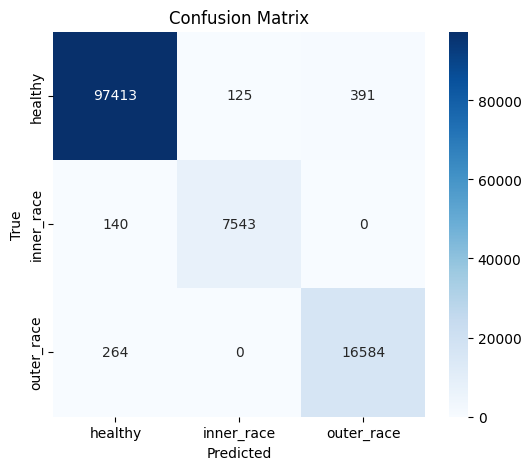

NotFittedError: No feature_importances found. Need to call fit beforehand.

In [ ]:
# -------------------- Imports --------------------
import os
import time
import numpy as np
import pandas as pd
from scipy.stats import skew, kurtosis
from scipy.fft import fft
from scipy.signal import hilbert

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectFromModel
from sklearn.model_selection import GroupKFold, cross_val_score, cross_val_predict
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------- Parameters --------------------
data_dir = "/content/mydata/IMS/"
window_size = 1024
stride = 512
sampling_rate = 20000

test_map = {
    "1st_test": "outer_race",
    "2nd_test": "inner_race",
    "3rd_test": "ball"
}

fault_map = {
    "healthy": 0,
    "inner_race": 1,
    "outer_race": 2,
    "ball": 3
}

# -------------------- Feature Extraction --------------------
def segment_signal(signal, window_size=1024, stride=512):
    if signal.ndim == 1:
        signal = signal[:, None]
    segments = []
    for start in range(0, signal.shape[0] - window_size + 1, stride):
        segments.append(signal[start:start+window_size])
    return np.array(segments)

def extract_features_multi_channel(segments, sampling_rate=20000):
    """Extract features for all channels and ensure consistent feature length"""
    X_feats = []
    expected_num_bands = 4
    expected_features_per_channel = 9 + 5 + expected_num_bands + 1  # time(9)+freq(5)+band(4)+envelope_rms(1)

    for seg in segments:
        feats = []
        for ch in range(seg.shape[1]):  # loop through all channels
            signal = seg[:, ch]

            # --- Time-domain ---
            mean_val = np.mean(signal)
            std_val = np.std(signal)
            rms = np.sqrt(np.mean(signal**2))
            peak_to_peak = np.ptp(signal)
            skew_val = skew(signal)
            kurt_val = kurtosis(signal)
            crest_factor = np.max(np.abs(signal)) / (rms + 1e-12)
            impulse_factor = np.max(np.abs(signal)) / (mean_val + 1e-12)
            shape_factor = rms / (mean_val + 1e-12)

            # --- Frequency-domain ---
            fft_vals = np.abs(fft(signal))[:len(signal)//2]
            freqs = np.fft.fftfreq(len(signal), d=1/sampling_rate)[:len(signal)//2]

            dominant_freq = freqs[np.argmax(fft_vals)]
            spectral_centroid = np.sum(freqs * fft_vals) / np.sum(fft_vals)
            spectral_bandwidth = np.sqrt(np.sum(((freqs - spectral_centroid)**2) * fft_vals) / np.sum(fft_vals))
            spectral_entropy = -np.sum((fft_vals/np.sum(fft_vals)) * np.log2(fft_vals/np.sum(fft_vals) + 1e-12))

            # Band energies
            band_edges = [0, 1000, 5000, 10000, sampling_rate//2]
            band_energies = []
            for i in range(len(band_edges)-1):
                mask = (freqs >= band_edges[i]) & (freqs < band_edges[i+1])
                band_energies.append(np.sum(fft_vals[mask]**2))
            # Pad band energies if needed
            while len(band_energies) < expected_num_bands:
                band_energies.append(0)

            # Envelope
            analytic_signal = hilbert(signal)
            envelope = np.abs(analytic_signal)
            envelope_rms = np.sqrt(np.mean(envelope**2))

            # Concatenate all features
            channel_feats = [mean_val, std_val, rms, peak_to_peak, skew_val, kurt_val,
                             crest_factor, impulse_factor, shape_factor,
                             dominant_freq, spectral_centroid, spectral_bandwidth,
                             spectral_entropy, envelope_rms] + band_energies

            # Ensure consistent feature length per channel
            if len(channel_feats) < expected_features_per_channel:
                channel_feats += [0]*(expected_features_per_channel - len(channel_feats))
            feats.extend(channel_feats)

        # Only append if features are not empty
        if feats:
            X_feats.append(feats)
    return np.array(X_feats)

# -------------------- Load & Process Data --------------------
X_all, y_all, groups = [], [], []
file_id = 0

for root, dirs, files in os.walk(data_dir):
    if len(files) == 0:
        continue

    folder_name = root.split(os.sep)[-2]
    fault_type = test_map.get(folder_name, None)
    if fault_type is None:
        continue

    files = sorted(files)
    split_idx = int(len(files) * 0.8)

    for i, f in enumerate(files):
        file_path = os.path.join(root, f)
        try:
            df = pd.read_csv(file_path, delim_whitespace=True, header=None)
            signal = df.values  # all channels
            segments = segment_signal(signal, window_size, stride)
            X_feats = extract_features_multi_channel(segments, sampling_rate)

            if X_feats.shape[0] == 0:
                continue  # skip empty segments

            label = fault_map["healthy"] if i < split_idx else fault_map[fault_type]
            y_labels = np.full(X_feats.shape[0], label)

            X_all.append(X_feats)
            y_all.append(y_labels)
            groups.extend([file_id] * X_feats.shape[0])
            file_id += 1

        except Exception as e:
            print(f"⚠️ Skipped {f}: {e}")

# -------------------- Stack Safely --------------------
# Ensure all arrays have same number of columns
max_cols = max(arr.shape[1] for arr in X_all)
X_all_fixed = [np.pad(arr, ((0,0),(0,max_cols-arr.shape[1])), 'constant') if arr.shape[1] < max_cols else arr for arr in X_all]

X = np.vstack(X_all_fixed)
y = np.hstack(y_all)
groups = np.array(groups)

print("Dataset shapes:", X.shape, y.shape, groups.shape)
print("Class distribution:", np.unique(y, return_counts=True))

# -------------------- Feature Scaling & Selection --------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

lgbm_fs = LGBMClassifier(n_estimators=300, random_state=42)
lgbm_fs.fit(X_scaled, y)
sfm = SelectFromModel(lgbm_fs, threshold="median", prefit=True)
X_selected = sfm.transform(X_scaled)
print(f"Selected {X_selected.shape[1]} features out of {X_scaled.shape[1]}")

# -------------------- Model Training & Evaluation --------------------
lgbm = LGBMClassifier(n_estimators=500, learning_rate=0.05, num_leaves=31, random_state=42)
gkf = GroupKFold(n_splits=5)

scores = cross_val_score(lgbm, X_selected, y, cv=gkf, groups=groups)
print(f"✅ LightGBM CV Accuracy: {scores} → Mean: {np.mean(scores):.4f}")

y_pred = cross_val_predict(lgbm, X_selected, y, cv=gkf, groups=groups)
labels = np.unique(y)
names = [k for k, v in fault_map.items() if v in labels]
print("Classification report:")
print(classification_report(y, y_pred, labels=labels, target_names=names))

# -------------------- Confusion Matrix --------------------
cm = confusion_matrix(y, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=names, yticklabels=names, cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

# -------------------- Fit final model to get feature importances --------------------
# THIS is where you fix the NotFittedError
lgbm.fit(X_selected, y)  # Fit on full dataset
importances = lgbm.feature_importances_

plt.figure(figsize=(10,4))
plt.bar(range(len(importances)), importances)
plt.xlabel("Feature Index")
plt.ylabel("Importance")
plt.title("LightGBM Feature Importances")
plt.show()



🔹 Evaluating RandomForest...
RandomForest CV Accuracy: [0.99044586 0.99085416 0.9910583  0.9914666  0.99191573] → Mean: 0.9911
Classification report:
              precision    recall  f1-score   support

     healthy       1.00      0.99      0.99     97929
  inner_race       0.98      0.98      0.98      7683
  outer_race       0.97      0.99      0.98     16848

    accuracy                           0.99    122460
   macro avg       0.98      0.99      0.98    122460
weighted avg       0.99      0.99      0.99    122460



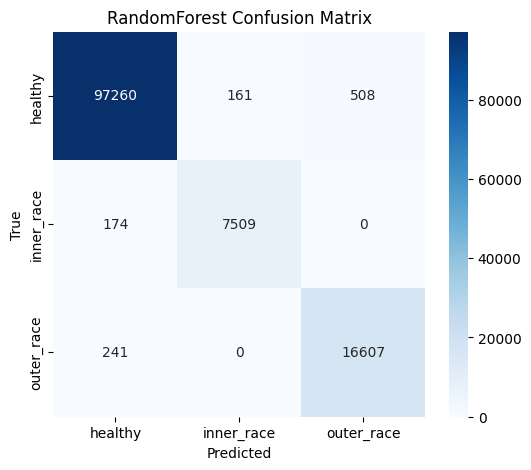


🔹 Evaluating GradientBoosting...


KeyboardInterrupt: 

In [ ]:
# # -------------------- Models --------------------
# from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
# from sklearn.svm import SVC
# from sklearn.neighbors import KNeighborsClassifier

# models = {
#     "RandomForest": RandomForestClassifier(n_estimators=100, random_state=42),
#     "GradientBoosting": GradientBoostingClassifier(n_estimators=100, random_state=42),
#     "XGBoost": XGBClassifier(n_estimators=100, use_label_encoder=False, eval_metric='mlogloss', random_state=42),
#     "LightGBM": LGBMClassifier(n_estimators=500, learning_rate=0.05, num_leaves=31, random_state=42),
#     "SVM": SVC(kernel='rbf', probability=True, random_state=42),
#     "KNN": KNeighborsClassifier(n_neighbors=5)
# }

# gkf = GroupKFold(n_splits=5)

# # -------------------- Run All Models --------------------
# for name, clf in models.items():
#     print(f"\n🔹 Evaluating {name}...")
#     try:
#         # Cross-validation accuracy
#         scores = cross_val_score(clf, X_selected, y, cv=gkf, groups=groups)
#         print(f"{name} CV Accuracy: {scores} → Mean: {np.mean(scores):.4f}")

#         # Detailed metrics
#         y_pred = cross_val_predict(clf, X_selected, y, cv=gkf, groups=groups)
#         labels = np.unique(y)
#         names = [k for k, v in fault_map.items() if v in labels]
#         print("Classification report:")
#         print(classification_report(y, y_pred, labels=labels, target_names=names))

#         cm = confusion_matrix(y, y_pred)
#         plt.figure(figsize=(6,5))
#         sns.heatmap(cm, annot=True, fmt='d', xticklabels=names, yticklabels=names, cmap="Blues")
#         plt.xlabel("Predicted")
#         plt.ylabel("True")
#         plt.title(f"{name} Confusion Matrix")
#         plt.show()

#         if hasattr(clf, "feature_importances_"):
#             importances = clf.feature_importances_
#             plt.figure(figsize=(10,4))
#             plt.bar(range(len(importances)), importances)
#             plt.xlabel("Feature Index")
#             plt.ylabel("Importance")
#             plt.title(f"{name} Feature Importances")
#             plt.show()
#     except Exception as e:
#         print(f"⚠️ Failed to evaluate {name}: {e}")


⚡ Large dataset detected → Using Fast SVM (RBF-approximation)

🔹 Evaluating SVM...
SVM CV Accuracy: [0.92671076 0.92650661 0.9318553  0.92536338 0.92699657] → Mean: 0.9275
Classification report:
              precision    recall  f1-score   support

     healthy       0.93      0.98      0.96     97929
  inner_race       0.90      0.62      0.74      7683
  outer_race       0.89      0.75      0.82     16848

    accuracy                           0.93    122460
   macro avg       0.91      0.79      0.84    122460
weighted avg       0.93      0.93      0.92    122460



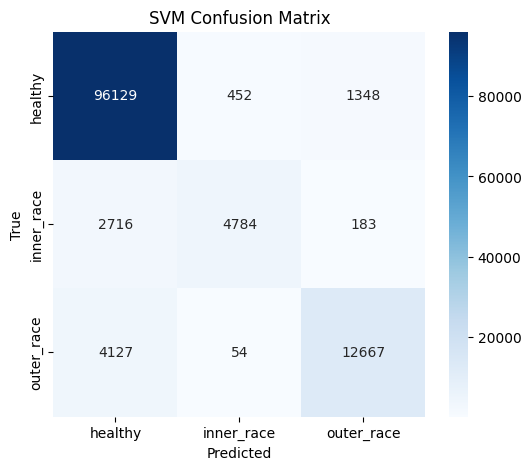


🔹 Evaluating KNN...
KNN CV Accuracy: [0.97574718 0.9763188  0.97758452 0.97460395 0.97517557] → Mean: 0.9759
Classification report:
              precision    recall  f1-score   support

     healthy       0.98      0.99      0.98     97929
  inner_race       0.93      0.86      0.89      7683
  outer_race       0.95      0.97      0.96     16848

    accuracy                           0.98    122460
   macro avg       0.95      0.94      0.95    122460
weighted avg       0.98      0.98      0.98    122460



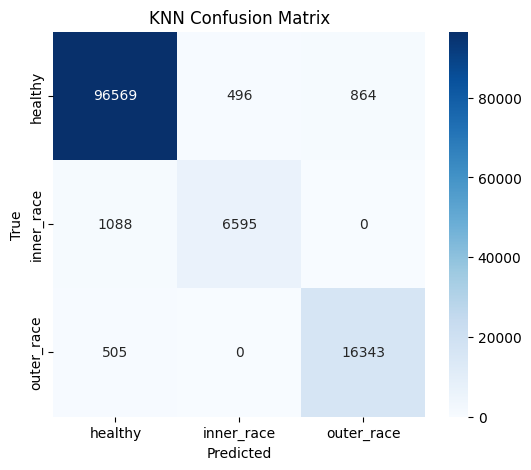

In [ ]:
# -------------------- Imports --------------------
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC, LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline
from sklearn.kernel_approximation import RBFSampler
from sklearn.linear_model import SGDClassifier
from sklearn.decomposition import PCA
from sklearn.model_selection import GroupKFold, cross_val_score, cross_val_predict
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler

# -------------------- Fault & Test Maps --------------------
fault_map = {
    "healthy": 0,
    "inner_race": 1,
    "outer_race": 2,
    "ball": 3
}

test_map = {
    "1st_test": "outer_race",
    "2nd_test": "inner_race",
    "3rd_test": "ball"
}


# -------------------- Auto-optimized SVM --------------------
n_samples, n_features = X_selected.shape

if n_samples > 50000:
    print("⚡ Large dataset detected → Using Fast SVM (RBF-approximation)")
    svm_model = make_pipeline(
        RBFSampler(gamma=0.1, n_components=500, random_state=42),
        SGDClassifier(loss="hinge", max_iter=1000, tol=1e-3, random_state=42, n_jobs=-1)
    )
elif n_features > 200:
    print("⚡ High-dimensional data detected → Using LinearSVC")
    svm_model = make_pipeline(
        LinearSVC(max_iter=5000, dual=False, random_state=42)
    )
else:
    print("✅ Using standard SVC (RBF)")
    svm_model = make_pipeline(
        SVC(kernel='rbf', probability=True, random_state=42, cache_size=1000)
    )

# -------------------- Fast KNN --------------------
fast_knn = make_pipeline(
    PCA(n_components=min(30, n_features), random_state=42),
    KNeighborsClassifier(n_neighbors=5, n_jobs=-1, algorithm='brute')
)

# -------------------- Model Dictionary --------------------
models = {
    "SVM": svm_model,
    "KNN": fast_knn
}

# -------------------- Cross-validation Setup --------------------
gkf = GroupKFold(n_splits=5)

# -------------------- Run All Models --------------------
for name, clf in models.items():
    print(f"\n🔹 Evaluating {name}...")
    try:
        # CV accuracy
        scores = cross_val_score(clf, X_selected, y, cv=gkf, groups=groups, n_jobs=-1)
        print(f"{name} CV Accuracy: {scores} → Mean: {np.mean(scores):.4f}")

        # CV predictions
        y_pred = cross_val_predict(clf, X_selected, y, cv=gkf, groups=groups, n_jobs=-1)
        labels = np.unique(y)

        # Robust label mapping
        try:
            inv_fault_map = {v:k for k,v in fault_map.items()}
            names = [inv_fault_map.get(v, f"Class {v}") for v in labels]
        except NameError:
            names = [f"Class {v}" for v in labels]

        print("Classification report:")
        print(classification_report(y, y_pred, labels=labels, target_names=names))

        # Confusion matrix
        cm = confusion_matrix(y, y_pred)
        plt.figure(figsize=(6,5))
        sns.heatmap(cm, annot=True, fmt='d', xticklabels=names, yticklabels=names, cmap="Blues")
        plt.xlabel("Predicted")
        plt.ylabel("True")
        plt.title(f"{name} Confusion Matrix")
        plt.show()

    except Exception as e:
        print(f"⚠️ Failed to evaluate {name}: {e}")


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Define your save path inside Drive
save_path = "/content/drive/MyDrive/Projects_AI_DS/bearing_fault/ims_features.npz"

# Save to the Drive path
np.savez_compressed(save_path, X=X, y=y, groups=groups)
print(f"✅ Features saved to {save_path}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


NameError: name 'X' is not defined

In [ ]:
import numpy as np

# -------------------- Fix arrays with mismatched columns --------------------
max_cols = max(arr.shape[1] for arr in X_all)  # find max feature length

X_all_fixed = [
    np.pad(arr, ((0, 0), (0, max_cols - arr.shape[1])), 'constant')
    if arr.shape[1] < max_cols else arr
    for arr in X_all
]

# -------------------- Stack arrays --------------------
X = np.vstack(X_all_fixed)
y = np.hstack(y_all)
groups = np.array(groups)

# -------------------- Save to Drive --------------------
save_path = "/content/drive/MyDrive/Projects_AI_DS/bearing_fault/ims_features.npz"
np.savez_compressed(save_path, X=X, y=y, groups=groups)
print(f"✅ Features saved to Drive at: {save_path}")


✅ Features saved to Drive at: /content/drive/MyDrive/Projects_AI_DS/bearing_fault/ims_features.npz


In [ ]:
import numpy as np

load_path = "/content/drive/MyDrive/Projects_AI_DS/bearing_fault/ims_features.npz"
data = np.load(load_path)
X, y, groups = data["X"], data["y"], data["groups"]

print("✅ Features loaded:", X.shape, y.shape)


✅ Features loaded: (122460, 152) (122460,)


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectFromModel
from lightgbm import LGBMClassifier

# -------------------- Scale --------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# -------------------- Optional Feature Selection --------------------
lgbm_fs = LGBMClassifier(n_estimators=300, random_state=42)
lgbm_fs.fit(X_scaled, y)
sfm = SelectFromModel(lgbm_fs, threshold="median", prefit=True)
X_selected = sfm.transform(X_scaled)

print(f"Selected {X_selected.shape[1]} features out of {X_scaled.shape[1]}")


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.555712 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 32413
[LightGBM] [Info] Number of data points in the train set: 122460, number of used features: 132
[LightGBM] [Info] Start training from score -0.223542
[LightGBM] [Info] Start training from score -2.768774
[LightGBM] [Info] Start training from score -1.983552
Selected 76 features out of 152


In [ ]:
# -------------------- Imports --------------------
import os, time
import numpy as np
from scipy.stats import skew, kurtosis
from scipy.fft import fft
from scipy.signal import hilbert
from concurrent.futures import ProcessPoolExecutor, as_completed

import pandas as pd

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline

from sklearn.model_selection import GroupKFold, cross_val_score, cross_val_predict
from sklearn.metrics import classification_report, confusion_matrix

# -------------------- Parameters --------------------
data_dir = "/content/mydata/IMS/"
window_size = 1024
stride = 512
sampling_rate = 20000  # Hz
n_workers = 8  # parallel workers, adjust as per CPU

test_map = {
    "1st_test": "outer_race",
    "2nd_test": "inner_race",
    "3rd_test": "ball"
}

fault_map = {
    "healthy": 0,
    "inner_race": 1,
    "outer_race": 2,
    "ball": 3
}

# -------------------- Feature Extraction --------------------
def segment_signal(signal, window_size=1024, stride=512):
    if signal.ndim == 1:
        signal = signal[:, None]
    segments = []
    for start in range(0, signal.shape[0] - window_size, stride):
        segments.append(signal[start:start+window_size])
    return np.array(segments)

def extract_features(segments, sampling_rate=20000):
    X_feats = []
    for seg in segments:
        feats = []
        signal = seg[:, 0]

        # Time-domain
        mean_val = np.mean(signal)
        std_val = np.std(signal)
        rms = np.sqrt(np.mean(signal**2))
        peak_to_peak = np.ptp(signal)
        skew_val = skew(signal)
        kurt_val = kurtosis(signal)
        crest_factor = np.max(np.abs(signal)) / (rms + 1e-12)
        impulse_factor = np.max(np.abs(signal)) / (mean_val + 1e-12)
        shape_factor = rms / (mean_val + 1e-12)
        feats.extend([mean_val, std_val, rms, peak_to_peak, skew_val, kurt_val,
                      crest_factor, impulse_factor, shape_factor])

        # Frequency-domain
        fft_vals = np.abs(fft(signal))
        freqs = np.fft.fftfreq(len(signal), d=1/sampling_rate)
        fft_vals, freqs = fft_vals[:len(signal)//2], freqs[:len(signal)//2]
        dominant_freq = freqs[np.argmax(fft_vals)]
        spectral_centroid = np.sum(freqs * fft_vals) / (np.sum(fft_vals) + 1e-12)
        spectral_bandwidth = np.sqrt(np.sum(((freqs - spectral_centroid)**2) * fft_vals) / (np.sum(fft_vals) + 1e-12))
        spectral_entropy = -np.sum((fft_vals/np.sum(fft_vals) + 1e-12) * np.log2(fft_vals/np.sum(fft_vals) + 1e-12))

        band_edges = [0, 1000, 5000, 10000, sampling_rate//2]
        band_energies = []
        for i in range(len(band_edges)-1):
            mask = (freqs >= band_edges[i]) & (freqs < band_edges[i+1])
            band_energies.append(np.sum(fft_vals[mask]**2))

        analytic_signal = hilbert(signal)
        envelope = np.abs(analytic_signal)
        envelope_rms = np.sqrt(np.mean(envelope**2))

        feats.extend([dominant_freq, spectral_centroid, spectral_bandwidth, spectral_entropy, envelope_rms])
        feats.extend(band_energies)

        X_feats.append(feats)

    return np.array(X_feats)

# -------------------- Helper --------------------
def get_fault_type(root, test_map):
    parts = root.split(os.sep)
    for p in reversed(parts):
        if p in test_map:
            return test_map[p]
    return None

def process_file(args):
    file_path, split_idx, fault_type, file_idx = args
    try:
        if os.path.getsize(file_path) == 0:
            return None
        signal = np.loadtxt(file_path)
        if signal.ndim == 2 and signal.shape[1] > 1:
            signal = signal[:, 0]

        segments = segment_signal(signal, window_size, stride)
        X_feats = extract_features(segments, sampling_rate)

        label = fault_map["healthy"] if file_idx < split_idx else fault_map[fault_type]
        y_labels = np.full(X_feats.shape[0], label)
        return X_feats, y_labels, file_idx
    except Exception as e:
        print(f"⚠️ Skipped {file_path}: {e}")
        return None

# -------------------- Load Data in Parallel --------------------
X_all, y_all, groups = [], [], []
file_id = 0
start_time = time.time()

tasks = []
for root, dirs, files in os.walk(data_dir):
    if len(files) == 0:
        continue
    fault_type = get_fault_type(root, test_map)
    if fault_type is None:
        continue

    files = sorted(files)
    split_idx = int(len(files) * 0.8)
    for i, f in enumerate(files):
        tasks.append((os.path.join(root, f), split_idx, fault_type, file_id + i))
    file_id += len(files)

# Parallel execution
with ProcessPoolExecutor(max_workers=n_workers) as executor:
    for res in executor.map(process_file, tasks):
        if res:
            X_feats, y_labels, fid = res
            X_all.append(X_feats)
            y_all.append(y_labels)
            groups.extend([fid]*X_feats.shape[0])

elapsed = (time.time() - start_time)/60
print(f"✅ Done. Total files processed: {file_id} in {elapsed:.2f} min")

# -------------------- Prepare Dataset --------------------
X = np.vstack(X_all)
y = np.hstack(y_all)
groups = np.array(groups)
print("Dataset shapes:", X.shape, y.shape, groups.shape)
print("Class distribution:", np.unique(y, return_counts=True))

# -------------------- Models --------------------
models = {
    "RandomForest": RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    # "GradientBoosting": GradientBoostingClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(n_estimators=100, use_label_encoder=False, eval_metric='mlogloss', random_state=42, n_jobs=-1),
    "LightGBM": LGBMClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    "SVM": Pipeline([('scaler', StandardScaler()), ('pca', PCA(n_components=0.95)), ('svm', SVC(kernel='rbf', probability=True, random_state=42))]),
    "KNN": Pipeline([('scaler', StandardScaler()), ('pca', PCA(n_components=0.95)), ('knn', KNeighborsClassifier(n_neighbors=5))])
}

gkf = GroupKFold(n_splits=5)
for name, clf in models.items():
    print(f"\n🔹 Evaluating {name}...")
    scores = cross_val_score(clf, X, y, cv=gkf, groups=groups, n_jobs=-1)
    print(f"{name} CV Accuracy: {scores} → Mean: {np.mean(scores):.4f}")

    y_pred = cross_val_predict(clf, X, y, cv=gkf, groups=groups, n_jobs=-1)
    existing_labels = np.unique(y)
    existing_names = [k for k, v in fault_map.items() if v in existing_labels]
    print("Classification report:")
    print(classification_report(y, y_pred, labels=existing_labels, target_names=existing_names))
    print("Confusion matrix:\n", confusion_matrix(y, y_pred))


✅ Done. Total files processed: 9464 in 14.69 min
Dataset shapes: (359632, 18) (359632,) (359632,)
Class distribution: (array([0, 1, 2, 3]), array([175826,  37392,  16416, 129998]))

🔹 Evaluating RandomForest...


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


RandomForest CV Accuracy: [0.72338533 0.7197848  0.71856146 0.72530375 0.72732836] → Mean: 0.7229
Classification report:
              precision    recall  f1-score   support

     healthy       0.74      0.77      0.75    175826
  inner_race       0.85      0.73      0.78     37392
  outer_race       0.66      0.25      0.36     16416
        ball       0.68      0.72      0.70    129998

    accuracy                           0.72    359632
   macro avg       0.73      0.62      0.65    359632
weighted avg       0.72      0.72      0.72    359632

Confusion matrix:
 [[135343   1531   2090  36862]
 [  2225  27261      0   7906]
 [ 12369      0   4047      0]
 [ 33372   3309      0  93317]]

🔹 Evaluating XGBoost...
XGBoost CV Accuracy: [0.73214335 0.72862624 0.72812578 0.73331109 0.73475576] → Mean: 0.7314


KeyboardInterrupt: 

In [ ]:
# ============================================================
# IMS Bearing Fault Detection – Full ML Pipeline
# ============================================================
import os, time
import numpy as np
import pandas as pd
from scipy.stats import skew, kurtosis
from scipy.fft import fft
from scipy.signal import hilbert
from concurrent.futures import ProcessPoolExecutor

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectFromModel
from sklearn.model_selection import GroupKFold, cross_val_score, cross_val_predict
from sklearn.metrics import classification_report, confusion_matrix
import joblib

# ============================================================
# Parameters
# ============================================================
data_dir = "/content/mydata/IMS/"
window_size = 1024
stride = 512
sampling_rate = 20000  # Hz
n_workers = 8

test_map = {
    "1st_test": "outer_race",
    "2nd_test": "inner_race",
    "3rd_test": "ball"
}

fault_map = {
    "healthy": 0,
    "inner_race": 1,
    "outer_race": 2,
    "ball": 3
}

# ============================================================
# Signal Segmentation
# ============================================================
def segment_signal(signal, window_size=1024, stride=512):
    if signal.ndim == 1:
        signal = signal[:, None]
    segments = []
    for start in range(0, signal.shape[0] - window_size, stride):
        segments.append(signal[start:start + window_size])
    return np.array(segments)

# ============================================================
# Feature Extraction
# ============================================================
def extract_features(segments, sampling_rate=20000):
    X_feats = []
    for seg in segments:
        feats = []
        signal = seg[:, 0]

        # --- Time domain ---
        mean_val = np.mean(signal)
        std_val = np.std(signal)
        rms = np.sqrt(np.mean(signal ** 2))
        peak_to_peak = np.ptp(signal)
        skew_val = skew(signal)
        kurt_val = kurtosis(signal)
        crest_factor = np.max(np.abs(signal)) / (rms + 1e-12)
        impulse_factor = np.max(np.abs(signal)) / (mean_val + 1e-12)
        shape_factor = rms / (mean_val + 1e-12)
        feats.extend([mean_val, std_val, rms, peak_to_peak, skew_val, kurt_val,
                      crest_factor, impulse_factor, shape_factor])

        # --- Frequency domain ---
        fft_vals = np.abs(fft(signal))
        freqs = np.fft.fftfreq(len(signal), d=1 / sampling_rate)
        fft_vals, freqs = fft_vals[:len(signal)//2], freqs[:len(signal)//2]

        dominant_freq = freqs[np.argmax(fft_vals)]
        spectral_centroid = np.sum(freqs * fft_vals) / (np.sum(fft_vals) + 1e-12)
        spectral_bandwidth = np.sqrt(np.sum(((freqs - spectral_centroid) ** 2) * fft_vals) / (np.sum(fft_vals) + 1e-12))
        spectral_entropy = -np.sum((fft_vals / np.sum(fft_vals) + 1e-12) *
                                   np.log2(fft_vals / np.sum(fft_vals) + 1e-12))

        band_edges = [0, 1000, 5000, 10000, sampling_rate // 2]
        band_energies = []
        for i in range(len(band_edges) - 1):
            mask = (freqs >= band_edges[i]) & (freqs < band_edges[i + 1])
            band_energies.append(np.sum(fft_vals[mask] ** 2))

        # --- Envelope features ---
        analytic_signal = hilbert(signal)
        envelope = np.abs(analytic_signal)
        envelope_rms = np.sqrt(np.mean(envelope ** 2))

        feats.extend([dominant_freq, spectral_centroid, spectral_bandwidth,
                      spectral_entropy, envelope_rms])
        feats.extend(band_energies)
        X_feats.append(feats)

    return np.array(X_feats)

# ============================================================
# Data Processing Helpers
# ============================================================
def get_fault_type(root, test_map):
    parts = root.split(os.sep)
    for p in reversed(parts):
        if p in test_map:
            return test_map[p]
    return None

def process_file(args):
    file_path, split_idx, fault_type, file_idx = args
    try:
        if os.path.getsize(file_path) == 0:
            return None
        signal = np.loadtxt(file_path)
        if signal.ndim == 2 and signal.shape[1] > 1:
            signal = signal[:, 0]

        segments = segment_signal(signal, window_size, stride)
        X_feats = extract_features(segments, sampling_rate)

        label = fault_map["healthy"] if file_idx < split_idx else fault_map[fault_type]
        y_labels = np.full(X_feats.shape[0], label)
        return X_feats, y_labels, file_idx
    except Exception as e:
        print(f"⚠️ Skipped {file_path}: {e}")
        return None

# ============================================================
# Parallel Data Loading
# ============================================================
X_all, y_all, groups = [], [], []
file_id = 0
start_time = time.time()

tasks = []
for root, _, files in os.walk(data_dir):
    if not files:
        continue
    fault_type = get_fault_type(root, test_map)
    if fault_type is None:
        continue

    files = sorted(files)
    split_idx = int(len(files) * 0.8)
    for i, f in enumerate(files):
        tasks.append((os.path.join(root, f), split_idx, fault_type, file_id + i))
    file_id += len(files)

with ProcessPoolExecutor(max_workers=n_workers) as executor:
    for res in executor.map(process_file, tasks):
        if res:
            X_feats, y_labels, fid = res
            X_all.append(X_feats)
            y_all.append(y_labels)
            groups.extend([fid] * X_feats.shape[0])

elapsed = (time.time() - start_time) / 60
print(f"✅ Done. Total files processed: {file_id} in {elapsed:.2f} min")

# ============================================================
# Dataset Assembly
# ============================================================
X = np.vstack(X_all)
y = np.hstack(y_all)
groups = np.array(groups)
print("Dataset shapes:", X.shape, y.shape, groups.shape)
print("Class distribution:", np.unique(y, return_counts=True))

# ============================================================
# Feature Scaling & Selection
# ============================================================
print("\n🔹 Scaling and feature selection...")
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

lgbm_fs = LGBMClassifier(n_estimators=300, random_state=42, n_jobs=-1)
lgbm_fs.fit(X_scaled, y)
sfm = SelectFromModel(lgbm_fs, threshold="median", prefit=True)
X_selected = sfm.transform(X_scaled)
print(f"Selected {X_selected.shape[1]} features out of {X_scaled.shape[1]}")

# Optionally save the scaler and selector
joblib.dump(scaler, "scaler.pkl")
joblib.dump(sfm, "feature_selector.pkl")

# ============================================================
# Model Definitions
# ============================================================
models = {
    "RandomForest": RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    "XGBoost": XGBClassifier(n_estimators=100, use_label_encoder=False, eval_metric='mlogloss', random_state=42, n_jobs=-1),
    "LightGBM": LGBMClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    "SVM": Pipeline([('scaler', StandardScaler()), ('pca', PCA(n_components=0.95)), ('svm', SVC(kernel='rbf', probability=True, random_state=42))]),
    "KNN": Pipeline([('scaler', StandardScaler()), ('pca', PCA(n_components=0.95)), ('knn', KNeighborsClassifier(n_neighbors=5))])
}

# ============================================================
# Cross-Validation Evaluation
# ============================================================
gkf = GroupKFold(n_splits=5)

for name, clf in models.items():
    print(f"\n🔹 Evaluating {name}...")
    scores = cross_val_score(clf, X_selected, y, cv=gkf, groups=groups, n_jobs=-1)
    print(f"{name} CV Accuracy: {scores} → Mean: {np.mean(scores):.4f}")

    y_pred = cross_val_predict(clf, X_selected, y, cv=gkf, groups=groups, n_jobs=-1)
    existing_labels = np.unique(y)
    existing_names = [k for k, v in fault_map.items() if v in existing_labels]
    print("Classification report:")
    print(classification_report(y, y_pred, labels=existing_labels, target_names=existing_names))
    print("Confusion matrix:\n", confusion_matrix(y, y_pred))


✅ Done. Total files processed: 9464 in 15.22 min
Dataset shapes: (359632, 18) (359632,) (359632,)
Class distribution: (array([0, 1, 2, 3]), array([175826,  37392,  16416, 129998]))

🔹 Scaling and feature selection...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.069837 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4135
[LightGBM] [Info] Number of data points in the train set: 359632, number of used features: 17
[LightGBM] [Info] Start training from score -0.715586
[LightGBM] [Info] Start training from score -2.263625
[LightGBM] [Info] Start training from score -3.086825
[LightGBM] [Info] Start training from score -1.017562
Selected 9 features out of 18

🔹 Evaluating RandomForest...
RandomForest CV Accuracy: [0.72135569 0.71986821 0.71735202 0.72428893 0.72545065] → Mean: 0.7217


KeyboardInterrupt: 

Streaming output truncated to the last 5000 lines.
 74%|███████▎  | 6958/9464 [1:01:08<12:55,  3.23it/s]/tmp/ipython-input-2067635829.py:122: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(file_path, delim_whitespace=True, header=None)
/tmp/ipython-input-2067635829.py:122: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(file_path, delim_whitespace=True, header=None)
 74%|███████▎  | 6959/9464 [1:01:09<12:50,  3.25it/s]/tmp/ipython-input-2067635829.py:122: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(file_path, delim_whitespace=True, header=None)
/tmp/ipython-input-2067635829.py:122: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is dep

✅ Processed 9464 files in 79.24 min
Dataset shapes: (369096, 152) (369096,) (369096,)
Class distribution: (array([0, 1, 2, 3]), array([180453,  38376,  16848, 133419]))
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.313659 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 30634
[LightGBM] [Info] Number of data points in the train set: 369096, number of used features: 132
[LightGBM] [Info] Start training from score -0.715586
[LightGBM] [Info] Start training from score -2.263625
[LightGBM] [Info] Start training from score -3.086825
[LightGBM] [Info] Start training from score -1.017562
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further sp

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.270228 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 19222
[LightGBM] [Info] Number of data points in the train set: 295269, number of used features: 76
[LightGBM] [Info] Start training from score -0.715452
[LightGBM] [Info] Start training from score -2.263852
[LightGBM] [Info] Start training from score -3.085642
[LightGBM] [Info] Start training from score -1.017828
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


...

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.288644 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 19224
[LightGBM] [Info] Number of data points in the train set: 295269, number of used features: 76
[LightGBM] [Info] Start training from score -0.715992
[LightGBM] [Info] Start training from score -2.263852
[LightGBM] [Info] Start training from score -3.085642
[LightGBM] [Info] Start training from score -1.017097
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.431795 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 19220
[LightGBM] [Info] Number of data points in the train set: 295308, number of used features: 76
[LightGBM] [Info] Start training from score -0.715584
[LightGBM] [Info] Start training from score -2.262714
[LightGBM] [Info] Start training from score -3.088668
[LightGBM] [Info] Start training from score -1.017595
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Classification report:
              precision    recall  f1-score   support

     healthy       0.97      0.96      0.97    180453
  inner_race       1.00      1.00      1.00     38376
  outer_race       0.98      0.99      0.98     16848
        ball       0.95      0.96      0.96    133419

    accuracy                           0.97    369096
   macro avg       0.97      0.98      0.98    369096
weighted avg       0.97      0.97      0.97    369096



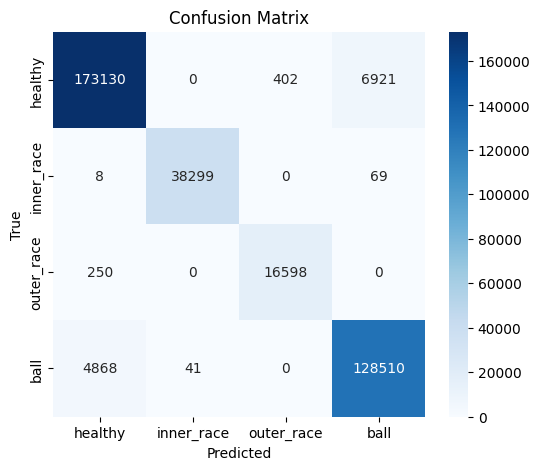

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.363777 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 19222
[LightGBM] [Info] Number of data points in the train set: 369096, number of used features: 76
[LightGBM] [Info] Start training from score -0.715586
[LightGBM] [Info] Start training from score -2.263625
[LightGBM] [Info] Start training from score -3.086825
[LightGBM] [Info] Start training from score -1.017562
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with

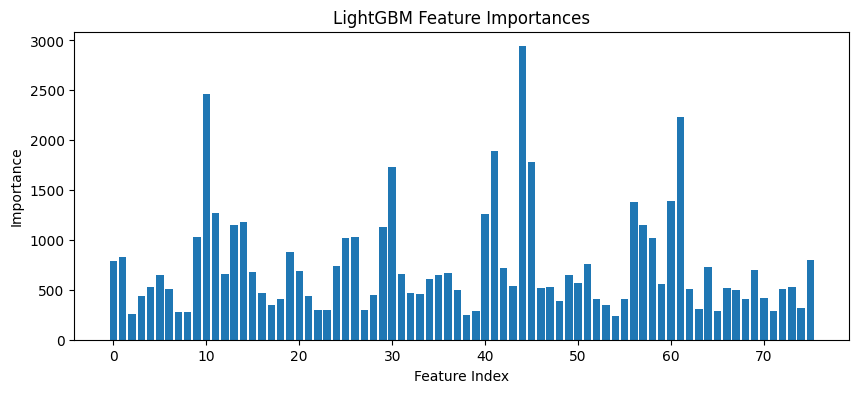

In [ ]:
# -------------------- Imports --------------------
import os
import time
import numpy as np
import pandas as pd
from scipy.stats import skew, kurtosis
from scipy.fft import fft
from scipy.signal import hilbert
from concurrent.futures import ProcessPoolExecutor
from tqdm import tqdm

from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectFromModel
from sklearn.model_selection import GroupKFold, cross_val_score, cross_val_predict
from sklearn.metrics import classification_report, confusion_matrix

from lightgbm import LGBMClassifier
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------- Parameters --------------------
data_dir = "/content/mydata/IMS/"
window_size = 1024
stride = 512
sampling_rate = 20000  # Hz
n_workers = 8  # Adjust based on CPU cores

test_map = {
    "1st_test": "outer_race",
    "2nd_test": "inner_race",
    "3rd_test": "ball"
}

fault_map = {
    "healthy": 0,
    "inner_race": 1,
    "outer_race": 2,
    "ball": 3
}

# -------------------- Feature Extraction --------------------
def segment_signal(signal, window_size=1024, stride=512):
    if signal.ndim == 1:
        signal = signal[:, None]
    segments = []
    for start in range(0, signal.shape[0] - window_size + 1, stride):
        segments.append(signal[start:start+window_size])
    return np.array(segments)


def extract_features_multi_channel(segments, sampling_rate=20000):
    """Extract features for all channels and ensure consistent feature length"""
    X_feats = []
    expected_num_bands = 4
    expected_features_per_channel = 9 + 5 + expected_num_bands + 1  # time(9)+freq(5)+band(4)+envelope_rms(1)

    for seg in segments:
        feats = []
        for ch in range(seg.shape[1]):  # all channels
            signal = seg[:, ch]

            # --- Time-domain ---
            mean_val = np.mean(signal)
            std_val = np.std(signal)
            rms = np.sqrt(np.mean(signal**2))
            peak_to_peak = np.ptp(signal)
            skew_val = skew(signal)
            kurt_val = kurtosis(signal)
            crest_factor = np.max(np.abs(signal)) / (rms + 1e-12)
            impulse_factor = np.max(np.abs(signal)) / (mean_val + 1e-12)
            shape_factor = rms / (mean_val + 1e-12)

            # --- Frequency-domain ---
            fft_vals = np.abs(fft(signal))[:len(signal)//2]
            freqs = np.fft.fftfreq(len(signal), d=1/sampling_rate)[:len(signal)//2]

            dominant_freq = freqs[np.argmax(fft_vals)]
            spectral_centroid = np.sum(freqs * fft_vals) / np.sum(fft_vals)
            spectral_bandwidth = np.sqrt(np.sum(((freqs - spectral_centroid)**2) * fft_vals) / np.sum(fft_vals))
            spectral_entropy = -np.sum((fft_vals/np.sum(fft_vals)) * np.log2(fft_vals/np.sum(fft_vals) + 1e-12))

            # Band energies
            band_edges = [0, 1000, 5000, 10000, sampling_rate//2]
            band_energies = []
            for i in range(len(band_edges)-1):
                mask = (freqs >= band_edges[i]) & (freqs < band_edges[i+1])
                band_energies.append(np.sum(fft_vals[mask]**2))
            while len(band_energies) < expected_num_bands:
                band_energies.append(0)

            # Envelope
            analytic_signal = hilbert(signal)
            envelope = np.abs(analytic_signal)
            envelope_rms = np.sqrt(np.mean(envelope**2))

            channel_feats = [mean_val, std_val, rms, peak_to_peak, skew_val, kurt_val,
                             crest_factor, impulse_factor, shape_factor,
                             dominant_freq, spectral_centroid, spectral_bandwidth,
                             spectral_entropy, envelope_rms] + band_energies

            if len(channel_feats) < expected_features_per_channel:
                channel_feats += [0]*(expected_features_per_channel - len(channel_feats))
            feats.extend(channel_feats)
        if feats:
            X_feats.append(feats)
    return np.array(X_feats)


# -------------------- File Processing --------------------
def get_fault_type(root):
    for part in reversed(root.split(os.sep)):
        if part in test_map:
            return test_map[part]
    return None


def process_file(args):
    file_path, split_idx, fault_type, file_id = args
    try:
        if os.path.getsize(file_path) == 0:
            return None
        df = pd.read_csv(file_path, delim_whitespace=True, header=None)
        signal = df.values
        segments = segment_signal(signal, window_size, stride)
        X_feats = extract_features_multi_channel(segments, sampling_rate)
        if X_feats.shape[0] == 0:
            return None
        label = fault_map["healthy"] if file_id < split_idx else fault_map[fault_type]
        y_labels = np.full(X_feats.shape[0], label)
        groups = [file_id]*X_feats.shape[0]
        return X_feats, y_labels, groups
    except Exception as e:
        print(f"⚠️ Skipped {file_path}: {e}")
        return None


# -------------------- Data Loading --------------------
X_all, y_all, groups = [], [], []
file_id = 0
tasks = []

for root, dirs, files in os.walk(data_dir):
    if len(files) == 0:
        continue
    fault_type = get_fault_type(root)
    if fault_type is None:
        continue

    files = sorted(files)
    split_idx = int(len(files) * 0.8)
    for i, f in enumerate(files):
        tasks.append((os.path.join(root, f), split_idx, fault_type, file_id + i))
    file_id += len(files)

start_time = time.time()
with ProcessPoolExecutor(max_workers=n_workers) as executor:
    for res in tqdm(executor.map(process_file, tasks), total=len(tasks)):
        if res:
            X_feats, y_labels, grp = res
            X_all.append(X_feats)
            y_all.append(y_labels)
            groups.extend(grp)
elapsed = (time.time() - start_time)/60
print(f"✅ Processed {file_id} files in {elapsed:.2f} min")

# -------------------- Stack Arrays --------------------
max_cols = max(arr.shape[1] for arr in X_all)
X_all_fixed = [np.pad(arr, ((0,0),(0,max_cols-arr.shape[1])), 'constant') if arr.shape[1]<max_cols else arr for arr in X_all]

X = np.vstack(X_all_fixed)
y = np.hstack(y_all)
groups = np.array(groups)
print("Dataset shapes:", X.shape, y.shape, groups.shape)
print("Class distribution:", np.unique(y, return_counts=True))

# -------------------- Feature Scaling & Selection --------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

lgbm_fs = LGBMClassifier(n_estimators=300, random_state=42)
lgbm_fs.fit(X_scaled, y)
sfm = SelectFromModel(lgbm_fs, threshold="median", prefit=True)
X_selected = sfm.transform(X_scaled)
print(f"Selected {X_selected.shape[1]} features out of {X_scaled.shape[1]}")

# -------------------- LightGBM Training & Evaluation --------------------
lgbm = LGBMClassifier(n_estimators=500, learning_rate=0.05, num_leaves=31, random_state=42)
gkf = GroupKFold(n_splits=5)

scores = cross_val_score(lgbm, X_selected, y, cv=gkf, groups=groups)
print(f"✅ LightGBM CV Accuracy: {scores} → Mean: {np.mean(scores):.4f}")

y_pred = cross_val_predict(lgbm, X_selected, y, cv=gkf, groups=groups)
labels = np.unique(y)
names = [k for k, v in fault_map.items() if v in labels]
print("Classification report:")
print(classification_report(y, y_pred, labels=labels, target_names=names))

# -------------------- Confusion Matrix --------------------
cm = confusion_matrix(y, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=names, yticklabels=names, cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

# -------------------- Feature Importances --------------------
lgbm.fit(X_selected, y)
importances = lgbm.feature_importances_
plt.figure(figsize=(10,4))
plt.bar(range(len(importances)), importances)
plt.xlabel("Feature Index")
plt.ylabel("Importance")
plt.title("LightGBM Feature Importances")
plt.show()


In [ ]:
import numpy as np
# Load later
data = np.load("/content/drive/MyDrive/ims_features_full_selected.npz")
X_scaled = data["X_scaled"]
X_selected = data["X_selected"]
y = data["y"]
groups = data["groups"]
print("✅ Scaled & selected features loaded from Drive.")


✅ Scaled & selected features loaded from Drive.


In [ ]:
X_selected.shape
# X.shape

(369096, 76)

In [ ]:
import time
import threading
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupKFold
from sklearn.metrics import classification_report, confusion_matrix

# -------------------- Random Forest Setup --------------------
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    n_jobs=-1,
    random_state=42
)

gkf = GroupKFold(n_splits=5)
scores = []
y_true_all, y_pred_all = [], []

def progress_logger(stop_event, fold):
    start = time.time()
    while not stop_event.is_set():
        elapsed = (time.time() - start) / 60
        print(f"🕒 [Fold {fold}] Still training... elapsed {elapsed:.1f} min")
        time.sleep(60)  # print every 1 minute

print("🚀 Starting GroupKFold cross-validation...\n")
total_start = time.time()

for fold, (train_idx, test_idx) in enumerate(gkf.split(X_selected, y, groups), 1):
    fold_start = time.time()
    print(f"\n📂 Fold {fold} started...")

    X_train, X_test = X_selected[train_idx], X_selected[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    # Start background thread for live progress
    stop_event = threading.Event()
    t = threading.Thread(target=progress_logger, args=(stop_event, fold))
    t.start()

    # Train model
    rf.fit(X_train, y_train)

    # Stop progress updates
    stop_event.set()
    t.join()

    print(f"✅ Fold {fold} training complete in {(time.time() - fold_start) / 60:.2f} min")

    y_pred = rf.predict(X_test)
    acc = np.mean(y_pred == y_test)
    scores.append(acc)
    y_true_all.extend(y_test)
    y_pred_all.extend(y_pred)

    print(f"📈 Fold {fold} Accuracy: {acc:.4f}")
    print(f"⏱ Total elapsed time: {(time.time() - total_start) / 60:.2f} min")

# -------------------- Final Evaluation --------------------
print("\n✅ Random Forest CV Accuracy per fold:", [round(s, 4) for s in scores])
print(f"Mean CV Accuracy: {np.mean(scores):.4f}")

labels = np.unique(y)
names = [k for k, v in fault_map.items() if v in labels]

print("\nClassification report:")
print(classification_report(y_true_all, y_pred_all, labels=labels, target_names=names))

# Confusion Matrix
cm = confusion_matrix(y_true_all, y_pred_all)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=names, yticklabels=names, cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

# Feature Importances
print("\n🔍 Calculating feature importances...")
rf.fit(X_selected, y)
importances = rf.feature_importances_

plt.figure(figsize=(10, 4))
plt.bar(range(len(importances)), importances)
plt.xlabel("Feature Index")
plt.ylabel("Importance")
plt.title("Random Forest Feature Importances")
plt.show()


🚀 Starting GroupKFold cross-validation...


📂 Fold 1 started...
🕒 [Fold 1] Still training... elapsed 0.0 min
🕒 [Fold 1] Still training... elapsed 1.0 min
🕒 [Fold 1] Still training... elapsed 2.0 min
🕒 [Fold 1] Still training... elapsed 3.0 min
🕒 [Fold 1] Still training... elapsed 4.0 min
🕒 [Fold 1] Still training... elapsed 5.0 min
🕒 [Fold 1] Still training... elapsed 6.0 min
🕒 [Fold 1] Still training... elapsed 7.0 min
🕒 [Fold 1] Still training... elapsed 8.0 min
🕒 [Fold 1] Still training... elapsed 9.0 min
✅ Fold 1 training complete in 10.01 min
📈 Fold 1 Accuracy: 0.9579
⏱ Total elapsed time: 10.04 min

📂 Fold 2 started...
🕒 [Fold 2] Still training... elapsed 0.0 min
🕒 [Fold 2] Still training... elapsed 1.0 min
🕒 [Fold 2] Still training... elapsed 2.0 min
🕒 [Fold 2] Still training... elapsed 3.0 min
🕒 [Fold 2] Still training... elapsed 4.0 min
🕒 [Fold 2] Still training... elapsed 5.0 min
🕒 [Fold 2] Still training... elapsed 6.0 min
🕒 [Fold 2] Still training... elapsed 7.0 min
🕒 [Fold

NameError: name 'fault_map' is not defined


Classification report:
              precision    recall  f1-score   support

     healthy       0.97      0.94      0.96    180453
  inner_race       1.00      1.00      1.00     38376
  outer_race       0.97      0.99      0.98     16848
        ball       0.93      0.96      0.95    133419

    accuracy                           0.96    369096
   macro avg       0.97      0.97      0.97    369096
weighted avg       0.96      0.96      0.96    369096



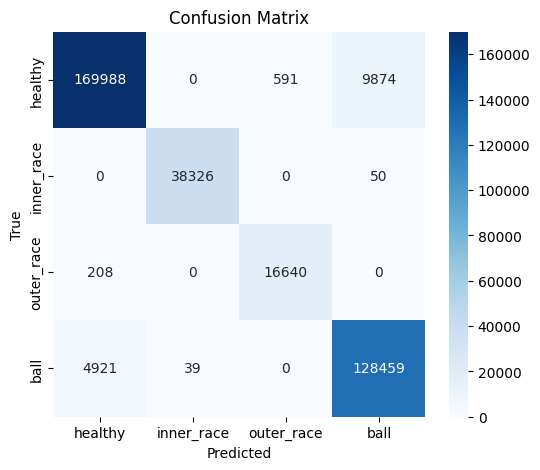


🔍 Calculating feature importances...


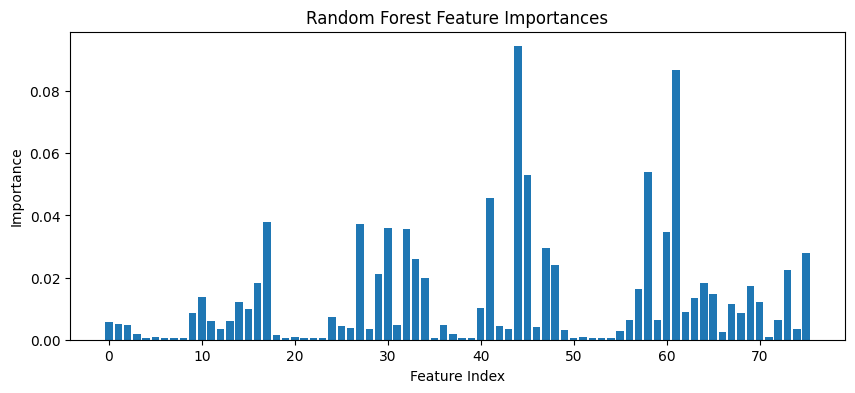

In [ ]:
# -------------------- Fault map --------------------
fault_map = {
    "healthy": 0,
    "inner_race": 1,
    "outer_race": 2,
    "ball": 3
}


labels = np.unique(y)
names = [k for k, v in fault_map.items() if v in labels]

print("\nClassification report:")
print(classification_report(y_true_all, y_pred_all, labels=labels, target_names=names))

# Confusion Matrix
cm = confusion_matrix(y_true_all, y_pred_all)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=names, yticklabels=names, cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

# Feature Importances
print("\n🔍 Calculating feature importances...")
rf.fit(X_selected, y)
importances = rf.feature_importances_

plt.figure(figsize=(10, 4))
plt.bar(range(len(importances)), importances)
plt.xlabel("Feature Index")
plt.ylabel("Importance")
plt.title("Random Forest Feature Importances")
plt.show()



🔹 Evaluating SVM...
🕒 [Fold 1] Training in progress... 0.0 min elapsed
✅ [Fold 1] Accuracy: 0.8755
🕒 [Fold 2] Training in progress... 0.0 min elapsed
✅ [Fold 2] Accuracy: 0.8715
🕒 [Fold 3] Training in progress... 0.0 min elapsed
✅ [Fold 3] Accuracy: 0.8769
🕒 [Fold 4] Training in progress... 0.0 min elapsed
✅ [Fold 4] Accuracy: 0.8764
🕒 [Fold 5] Training in progress... 0.0 min elapsed
✅ [Fold 5] Accuracy: 0.8739

SVM CV Accuracy per fold: [np.float64(0.8754791607406505), np.float64(0.8715104230159698), np.float64(0.8768878594552129), np.float64(0.8764408685169383), np.float64(0.8739361413780018)]
SVM Mean CV Accuracy: 0.8749

Classification report:
              precision    recall  f1-score   support

     healthy       0.88      0.89      0.88    180453
  inner_race       0.92      0.88      0.90     38376
  outer_race       0.90      0.73      0.80     16848
        ball       0.86      0.88      0.87    133419

    accuracy                           0.87    369096
   macro avg     

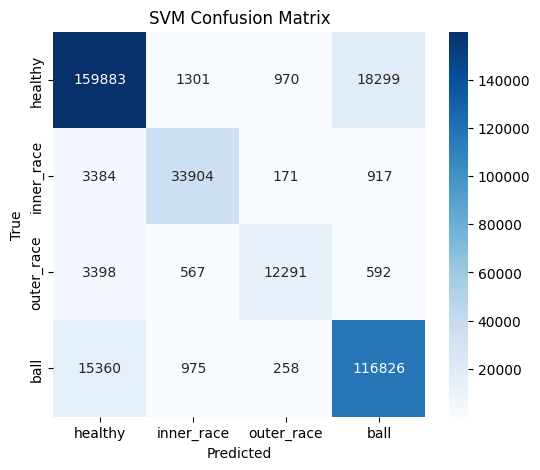


🔹 Evaluating KNN...
🕒 [Fold 1] Training in progress... 0.0 min elapsed
🕒 [Fold 1] Training in progress... 1.0 min elapsed
🕒 [Fold 1] Training in progress... 2.0 min elapsed
✅ [Fold 1] Accuracy: 0.8945
🕒 [Fold 2] Training in progress... 0.0 min elapsed
🕒 [Fold 2] Training in progress... 1.0 min elapsed
🕒 [Fold 2] Training in progress... 2.0 min elapsed
✅ [Fold 2] Accuracy: 0.8967
🕒 [Fold 3] Training in progress... 0.0 min elapsed
🕒 [Fold 3] Training in progress... 1.0 min elapsed
🕒 [Fold 3] Training in progress... 2.0 min elapsed
✅ [Fold 3] Accuracy: 0.8977
🕒 [Fold 4] Training in progress... 0.0 min elapsed
🕒 [Fold 4] Training in progress... 1.0 min elapsed
🕒 [Fold 4] Training in progress... 2.0 min elapsed
✅ [Fold 4] Accuracy: 0.8956
🕒 [Fold 5] Training in progress... 0.0 min elapsed
🕒 [Fold 5] Training in progress... 1.0 min elapsed
🕒 [Fold 5] Training in progress... 2.0 min elapsed
✅ [Fold 5] Accuracy: 0.8994

KNN CV Accuracy per fold: [np.float64(0.8944695030273477), np.float64(0.8

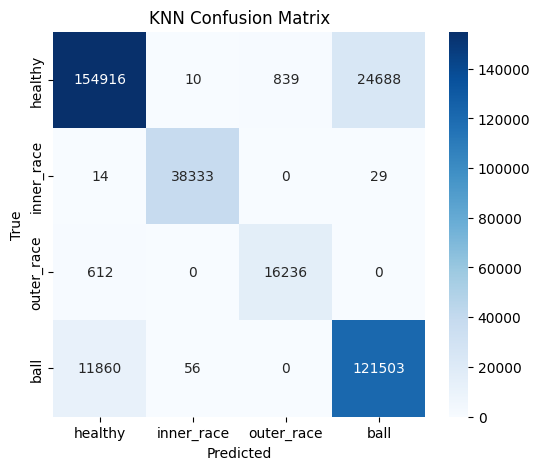

In [ ]:
import numpy as np
import time
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GroupKFold
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.pipeline import make_pipeline
from sklearn.decomposition import PCA
from sklearn.kernel_approximation import RBFSampler
from sklearn.linear_model import SGDClassifier
from sklearn.svm import SVC, LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from threading import Thread, Event

# -------------------- Fault map --------------------
fault_map = {
    "healthy": 0,
    "inner_race": 1,
    "outer_race": 2,
    "ball": 3
}

# -------------------- Models --------------------
n_samples, n_features = X_selected.shape

# SVM setup (exact as your code)
if n_samples > 50000:
    svm_model = make_pipeline(
        RBFSampler(gamma=0.1, n_components=500, random_state=42),
        SGDClassifier(loss="hinge", max_iter=1000, tol=1e-3, random_state=42, n_jobs=-1)
    )
elif n_features > 200:
    svm_model = make_pipeline(
        LinearSVC(max_iter=5000, dual=False, random_state=42)
    )
else:
    svm_model = make_pipeline(
        SVC(kernel='rbf', probability=True, random_state=42, cache_size=1000)
    )

# KNN setup (exact as your code)
fast_knn = make_pipeline(
    PCA(n_components=min(30, n_features), random_state=42),
    KNeighborsClassifier(n_neighbors=5, n_jobs=-1, algorithm='brute')
)

models = {
    "SVM": svm_model,
    "KNN": fast_knn
}

# -------------------- GroupKFold --------------------
gkf = GroupKFold(n_splits=5)

# -------------------- Progress Logger --------------------
def progress_logger(stop_event, fold_name):
    start_time = time.time()
    while not stop_event.is_set():
        elapsed = (time.time() - start_time) / 60
        print(f"🕒 [Fold {fold_name}] Training in progress... {elapsed:.1f} min elapsed")
        time.sleep(60)

# -------------------- Manual CV Loop --------------------
for name, clf in models.items():
    print(f"\n🔹 Evaluating {name}...")

    scores = []
    y_true_all, y_pred_all = [], []

    for fold, (train_idx, test_idx) in enumerate(gkf.split(X_selected, y, groups), 1):
        X_train, X_test = X_selected[train_idx], X_selected[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        stop_event = Event()
        thread = Thread(target=progress_logger, args=(stop_event, fold))
        thread.start()

        # Train and predict
        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)

        stop_event.set()
        thread.join()

        acc = np.mean(y_pred == y_test)
        scores.append(acc)

        y_true_all.extend(y_test)
        y_pred_all.extend(y_pred)

        print(f"✅ [Fold {fold}] Accuracy: {acc:.4f}")

    # -------------------- CV Results --------------------
    mean_cv = np.mean(scores)
    print(f"\n{name} CV Accuracy per fold: {scores}")
    print(f"{name} Mean CV Accuracy: {mean_cv:.4f}")

    # Classification report
    labels = np.unique(y)
    inv_fault_map = {v:k for k,v in fault_map.items()}
    target_names = [inv_fault_map.get(v, f"Class {v}") for v in labels]

    print("\nClassification report:")
    print(classification_report(y_true_all, y_pred_all, labels=labels, target_names=target_names))

    # Confusion matrix
    cm = confusion_matrix(y_true_all, y_pred_all)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=target_names, yticklabels=target_names, cmap="Blues")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(f"{name} Confusion Matrix")
    plt.show()


In [ ]:
import numpy as np
import time
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GroupKFold
from sklearn.metrics import classification_report, confusion_matrix
from threading import Thread, Event
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

# -------------------- Fault map --------------------
fault_map = {
    "healthy": 0,
    "inner_race": 1,
    "outer_race": 2,
    "ball": 3
}

# -------------------- Models --------------------
# Light, fast configurations tuned for speed
gb_model = GradientBoostingClassifier(
    n_estimators=200,       # Reduced for speed
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)

xgb_model = XGBClassifier(
    n_estimators=200,       # Fast config
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method="hist",     # FASTEST mode (use "gpu_hist" if GPU available)
    random_state=42,
    n_jobs=-1,
    verbosity=0
)

models = {
    "GradientBoosting": gb_model,
    "XGBoost": xgb_model
}

# -------------------- GroupKFold --------------------
gkf = GroupKFold(n_splits=5)

# -------------------- Progress Logger --------------------
def progress_logger(stop_event, fold_name):
    start_time = time.time()
    while not stop_event.is_set():
        elapsed = (time.time() - start_time) / 60
        print(f"🕒 [Fold {fold_name}] Training in progress... {elapsed:.1f} min elapsed")
        time.sleep(60)

# -------------------- Manual CV Loop --------------------
for name, clf in models.items():
    print(f"\n🔹 Evaluating {name}...")

    scores = []
    y_true_all, y_pred_all = [], []

    for fold, (train_idx, test_idx) in enumerate(gkf.split(X_selected, y, groups), 1):
        X_train, X_test = X_selected[train_idx], X_selected[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        stop_event = Event()
        thread = Thread(target=progress_logger, args=(stop_event, fold))
        thread.start()

        # Train and predict
        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)

        stop_event.set()
        thread.join()

        acc = np.mean(y_pred == y_test)
        scores.append(acc)

        y_true_all.extend(y_test)
        y_pred_all.extend(y_pred)

        print(f"✅ [Fold {fold}] Accuracy: {acc:.4f}")

    # -------------------- CV Results --------------------
    mean_cv = np.mean(scores)
    print(f"\n{name} CV Accuracy per fold: {scores}")
    print(f"{name} Mean CV Accuracy: {mean_cv:.4f}")

    # Classification report
    labels = np.unique(y)
    inv_fault_map = {v: k for k, v in fault_map.items()}
    target_names = [inv_fault_map.get(v, f"Class {v}") for v in labels]

    print("\nClassification report:")
    print(classification_report(y_true_all, y_pred_all, labels=labels, target_names=target_names))

    # Confusion matrix
    cm = confusion_matrix(y_true_all, y_pred_all)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d',
                xticklabels=target_names, yticklabels=target_names, cmap="Blues")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(f"{name} Confusion Matrix")
    plt.show()



🔹 Evaluating GradientBoosting...
🕒 [Fold 1] Training in progress... 0.0 min elapsed
🕒 [Fold 1] Training in progress... 1.0 min elapsed
🕒 [Fold 1] Training in progress... 2.0 min elapsed
🕒 [Fold 1] Training in progress... 3.0 min elapsed
🕒 [Fold 1] Training in progress... 4.0 min elapsed
🕒 [Fold 1] Training in progress... 5.0 min elapsed
🕒 [Fold 1] Training in progress... 6.0 min elapsed
🕒 [Fold 1] Training in progress... 7.0 min elapsed
🕒 [Fold 1] Training in progress... 8.0 min elapsed
🕒 [Fold 1] Training in progress... 9.0 min elapsed
🕒 [Fold 1] Training in progress... 10.0 min elapsed
🕒 [Fold 1] Training in progress... 11.0 min elapsed
🕒 [Fold 1] Training in progress... 12.0 min elapsed
🕒 [Fold 1] Training in progress... 13.0 min elapsed
🕒 [Fold 1] Training in progress... 14.0 min elapsed
🕒 [Fold 1] Training in progress... 15.0 min elapsed
🕒 [Fold 1] Training in progress... 16.0 min elapsed
🕒 [Fold 1] Training in progress... 17.0 min elapsed
🕒 [Fold 1] Training in progress... 18.0 


🔹 Evaluating XGBoost...
🕒 [Fold 1] Training in progress... 0.0 min elapsed
🕒 [Fold 1] Training in progress... 1.0 min elapsed
✅ [Fold 1] Accuracy: 0.9632
🕒 [Fold 2] Training in progress... 0.0 min elapsed
🕒 [Fold 2] Training in progress... 1.0 min elapsed
✅ [Fold 2] Accuracy: 0.9604
🕒 [Fold 3] Training in progress... 0.0 min elapsed
🕒 [Fold 3] Training in progress... 1.0 min elapsed
✅ [Fold 3] Accuracy: 0.9618
🕒 [Fold 4] Training in progress... 0.0 min elapsed
🕒 [Fold 4] Training in progress... 1.0 min elapsed
✅ [Fold 4] Accuracy: 0.9626
🕒 [Fold 5] Training in progress... 0.0 min elapsed
🕒 [Fold 5] Training in progress... 1.0 min elapsed
✅ [Fold 5] Accuracy: 0.9629

XGBoost CV Accuracy per fold: [np.float64(0.9632248364419521), np.float64(0.9604074390128273), np.float64(0.9618432280872852), np.float64(0.9626423937042003), np.float64(0.9629479048083699)]
XGBoost Mean CV Accuracy: 0.9622

Classification report:
              precision    recall  f1-score   support

     healthy       0.

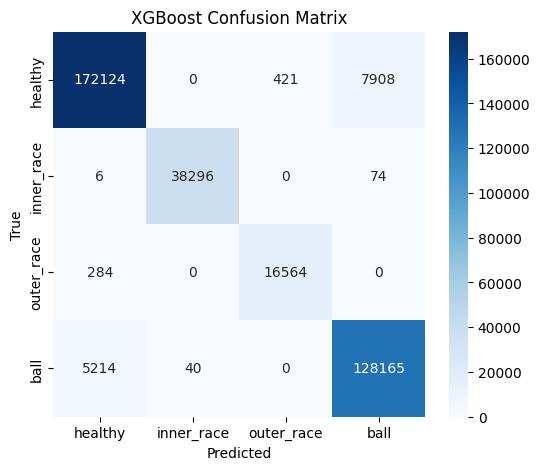

In [ ]:
import numpy as np
import time
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GroupKFold
from sklearn.metrics import classification_report, confusion_matrix
from threading import Thread, Event
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

# -------------------- Fault map --------------------
fault_map = {
    "healthy": 0,
    "inner_race": 1,
    "outer_race": 2,
    "ball": 3
}

# -------------------- Models --------------------
# Light, fast configurations tuned for speed

xgb_model = XGBClassifier(
    n_estimators=200,       # Fast config
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method="hist",     # FASTEST mode (use "gpu_hist" if GPU available)
    random_state=42,
    n_jobs=-1,
    verbosity=0
)

models = {
    # "GradientBoosting": gb_model,
    "XGBoost": xgb_model
}

# -------------------- GroupKFold --------------------
gkf = GroupKFold(n_splits=5)

# -------------------- Progress Logger --------------------
def progress_logger(stop_event, fold_name):
    start_time = time.time()
    while not stop_event.is_set():
        elapsed = (time.time() - start_time) / 60
        print(f"🕒 [Fold {fold_name}] Training in progress... {elapsed:.1f} min elapsed")
        time.sleep(60)

# -------------------- Manual CV Loop --------------------
for name, clf in models.items():
    print(f"\n🔹 Evaluating {name}...")

    scores = []
    y_true_all, y_pred_all = [], []

    for fold, (train_idx, test_idx) in enumerate(gkf.split(X_selected, y, groups), 1):
        X_train, X_test = X_selected[train_idx], X_selected[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        stop_event = Event()
        thread = Thread(target=progress_logger, args=(stop_event, fold))
        thread.start()

        # Train and predict
        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)

        stop_event.set()
        thread.join()

        acc = np.mean(y_pred == y_test)
        scores.append(acc)

        y_true_all.extend(y_test)
        y_pred_all.extend(y_pred)

        print(f"✅ [Fold {fold}] Accuracy: {acc:.4f}")

    # -------------------- CV Results --------------------
    mean_cv = np.mean(scores)
    print(f"\n{name} CV Accuracy per fold: {scores}")
    print(f"{name} Mean CV Accuracy: {mean_cv:.4f}")

    # Classification report
    labels = np.unique(y)
    inv_fault_map = {v: k for k, v in fault_map.items()}
    target_names = [inv_fault_map.get(v, f"Class {v}") for v in labels]

    print("\nClassification report:")
    print(classification_report(y_true_all, y_pred_all, labels=labels, target_names=target_names))

    # Confusion matrix
    cm = confusion_matrix(y_true_all, y_pred_all)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d',
                xticklabels=target_names, yticklabels=target_names, cmap="Blues")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(f"{name} Confusion Matrix")
    plt.show()


In [ ]:
import numpy as np

# Save everything
np.savez_compressed(
    "/content/drive/MyDrive/ims_features_full_selected.npz",
    X_scaled=X_scaled,          # scaled full features
    X_selected=X_selected,      # features after LightGBM selection
    y=y,
    groups=groups
)
print("✅ Scaled & selected features saved to Drive.")


✅ Scaled & selected features saved to Drive.


In [ ]:
# -------------------- Imports --------------------
import os, time
import numpy as np
import pandas as pd
from scipy.stats import skew, kurtosis
from scipy.fft import fft
from scipy.signal import hilbert
from concurrent.futures import ProcessPoolExecutor
from tqdm import tqdm

from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectFromModel
from sklearn.model_selection import GroupKFold, cross_val_score, cross_val_predict
from sklearn.metrics import classification_report, confusion_matrix
from lightgbm import LGBMClassifier
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------- Parameters --------------------
data_dir = "/content/mydata/IMS/"
window_size = 1024
stride = 512
sampling_rate = 20000
n_workers = 8

test_map = {"1st_test":"outer_race", "2nd_test":"inner_race", "3rd_test":"ball"}
fault_map = {"healthy":0, "inner_race":1, "outer_race":2, "ball":3}

# -------------------- Feature Extraction --------------------
def segment_signal(signal, window_size, stride):
    if signal.ndim==1: signal = signal[:,None]
    num_segments = (signal.shape[0]-window_size)//stride + 1
    return np.array([signal[i*stride:i*stride+window_size] for i in range(num_segments)])

def extract_features_multi_channel(segments):
    X_feats=[]
    expected_num_bands=4
    expected_features_per_channel=9+5+expected_num_bands+1
    for seg in segments:
        feats=[]
        for ch in range(seg.shape[1]):
            signal = seg[:,ch]
            mean_val,std_val = np.mean(signal),np.std(signal)
            rms = np.sqrt(np.mean(signal**2))
            peak_to_peak = np.ptp(signal)
            skew_val,kurt_val = skew(signal),kurtosis(signal)
            crest_factor = np.max(np.abs(signal))/(rms+1e-12)
            impulse_factor = np.max(np.abs(signal))/(mean_val+1e-12)
            shape_factor = rms/(mean_val+1e-12)
            fft_vals = np.abs(fft(signal))[:len(signal)//2]
            freqs = np.fft.fftfreq(len(signal),1/sampling_rate)[:len(signal)//2]
            dominant_freq = freqs[np.argmax(fft_vals)]
            spectral_centroid = np.sum(freqs*fft_vals)/np.sum(fft_vals)
            spectral_bandwidth = np.sqrt(np.sum((freqs-spectral_centroid)**2*fft_vals)/np.sum(fft_vals))
            spectral_entropy = -np.sum((fft_vals/np.sum(fft_vals))*np.log2(fft_vals/np.sum(fft_vals)+1e-12))
            band_edges = [0,1000,5000,10000,sampling_rate//2]
            band_energies = [np.sum(fft_vals[(freqs>=band_edges[i]) & (freqs<band_edges[i+1])]**2) for i in range(len(band_edges)-1)]
            while len(band_energies)<expected_num_bands: band_energies.append(0)
            envelope_rms = np.sqrt(np.mean(np.abs(hilbert(signal))**2))
            channel_feats=[mean_val,std_val,rms,peak_to_peak,skew_val,kurt_val,
                           crest_factor,impulse_factor,shape_factor,
                           dominant_freq,spectral_centroid,spectral_bandwidth,
                           spectral_entropy,envelope_rms]+band_energies
            if len(channel_feats)<expected_features_per_channel:
                channel_feats+=[0]*(expected_features_per_channel-len(channel_feats))
            feats.extend(channel_feats)
        if feats: X_feats.append(feats)
    return np.array(X_feats)

# -------------------- Process single file --------------------
def process_file(file_path, split_idx, fault_type, file_id):
    try:
        if os.path.getsize(file_path)==0: return None
        signal = pd.read_csv(file_path, delim_whitespace=True, header=None).values
        segments = segment_signal(signal, window_size, stride)
        X_feats = extract_features_multi_channel(segments)
        if X_feats.shape[0]==0: return None
        label = fault_map["healthy"] if file_id<split_idx else fault_map[fault_type]
        y_labels = np.full(X_feats.shape[0], label)
        groups = np.full(X_feats.shape[0], file_id)
        return X_feats, y_labels, groups
    except Exception as e:
        print(f"⚠️ Skipped {file_path}: {e}")
        return None

# -------------------- Prepare tasks --------------------
X_all, y_all, groups_all = [], [], []
tasks=[]
file_id=0
for root, dirs, files in os.walk(data_dir):
    if len(files)==0: continue
    folder_name = root.split(os.sep)[-2]
    fault_type = test_map.get(folder_name)
    if fault_type is None: continue
    files = sorted(files)
    split_idx = int(len(files)*0.8)
    for i,f in enumerate(files):
        tasks.append((os.path.join(root,f),split_idx,fault_type,file_id+i))
    file_id+=len(files)

# -------------------- Parallel processing --------------------
start=time.time()
with ProcessPoolExecutor(max_workers=n_workers) as executor:
    for res in tqdm(executor.map(lambda p: process_file(*p), tasks), total=len(tasks)):
        if res:
            X_feats, y_labels, grp = res
            X_all.append(X_feats)
            y_all.append(y_labels)
            groups_all.extend(grp)
elapsed=(time.time()-start)/60
print(f"✅ Processed {file_id} files in {elapsed:.2f} min")

# -------------------- Stack Arrays --------------------
max_cols = max(arr.shape[1] for arr in X_all)
X_all_fixed=[np.pad(arr,((0,0),(0,max_cols-arr.shape[1])),constant_values=0) if arr.shape[1]<max_cols else arr for arr in X_all]
X = np.vstack(X_all_fixed)
y = np.hstack(y_all)
groups = np.array(groups_all)
print("Dataset shapes:", X.shape, y.shape, groups.shape)
print("Class distribution:", np.unique(y,return_counts=True))

# -------------------- Feature Scaling & Selection --------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
lgbm_fs = LGBMClassifier(n_estimators=300,random_state=42)
lgbm_fs.fit(X_scaled,y)
sfm = SelectFromModel(lgbm_fs, threshold="median", prefit=True)
X_selected = sfm.transform(X_scaled)
print(f"Selected {X_selected.shape[1]} features out of {X_scaled.shape[1]}")

# -------------------- LightGBM Training & Evaluation --------------------
lgbm = LGBMClassifier(n_estimators=500, learning_rate=0.05, num_leaves=31, random_state=42)
gkf = GroupKFold(n_splits=5)
scores = cross_val_score(lgbm,X_selected,y,cv=gkf,groups=groups)
print(f"✅ CV Accuracy: {scores} → Mean: {np.mean(scores):.4f}")

y_pred = cross_val_predict(lgbm,X_selected,y,cv=gkf,groups=groups)
labels=np.unique(y)
names=[k for k,v in fault_map.items() if v in labels]
print(classification_report(y,y_pred,labels=labels,target_names=names))

cm=confusion_matrix(y,y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm,annot=True,fmt='d',xticklabels=names,yticklabels=names,cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

# -------------------- Feature Importances --------------------
lgbm.fit(X_selected,y)
plt.figure(figsize=(12,4))
plt.bar(range(len(lgbm.feature_importances_)),lgbm.feature_importances_)
plt.xlabel("Feature Index")
plt.ylabel("Importance")
plt.title("LightGBM Feature Importances")
plt.show()
